# Solar Energy Production Zones: Clustering

A solar power company is expanding into new regions and wants to know which areas are best for solar energy. In this project I group geographical areas by how much solar energy they produce, using clustering, so the company can focus its sales and marketing on the high-production zones.

The final output is a map that shows the clusters.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import zipcodes

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
data_path = 'Statewide Solar Projects.csv'

## 1. Data Loading

Load the solar projects data. The dataset has no coordinates, so I look up latitude and longitude for each ZIP code with the `zipcodes` library. I need them to plot the clusters on a map.

In [2]:
df = pd.read_csv(data_path, low_memory=False)
print(df.shape)

# the data has no coordinates, so get lat/long from the zip codes
rows = []
for z in df['Zip'].dropna().unique():
    try:
        zc = str(int(float(z))).zfill(5)
        match = zipcodes.matching(zc)[0]
        rows.append({'Zip': zc, 'Latitude': float(match['lat']), 'Longitude': float(match['long'])})
    except (ValueError, IndexError):
        continue

zip_latlong = pd.DataFrame(rows)
print(len(zip_latlong), 'zip codes found')

(218115, 17)
1728 zip codes found


## 2. Data Understanding

A first look at the data: columns and types, missing values and duplicates.

In [3]:
df.info()
display(df.head())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            218115 non-null  object 
 1   Project ID                                   218112 non-null  object 
 2   Interconnection Date                         218115 non-null  object 
 3   Utility                                      218115 non-null  object 
 4   City/Town                                    218057 non-null  object 
 5   County                                       218115 non-null  object 
 6   Zip                                          218019 non-null  float64
 7   Division                                     132881 non-null  object 
 8   Substation                                   138171 non-null  object 
 9   Circuit ID                                   218085 non-nul

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


,Zip,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
count,218019.000000,218115.000000,218115.000000,2.181150e+05,4091.000000,218115.0
mean,11751.734473,24.507977,19.065451,2.876828e+04,32.174727,1.0
std,962.129108,291.525394,211.419642,3.422042e+05,296.161116,0.0
min,10001.000000,0.010000,0.010000,1.400000e+01,0.350000,1.0
25%,11220.000000,5.270000,4.500000,6.180000e+03,5.000000,1.0
50%,11717.000000,7.130000,6.090000,8.364000e+03,7.600000,1.0
75%,12018.000000,10.240000,8.750000,1.201700e+04,10.000000,1.0
max,14905.000000,43470.000000,31500.000000,5.102682e+07,5000.000000,1.0


In [4]:
# missing values
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

# duplicates
print('duplicate rows:', df.duplicated().sum())
print('duplicate project ids:', df['Project ID'].duplicated().sum())

Energy Storage System Size (kWac)    214024
Division                              85234
Substation                            79944
Developer                             10550
Metering Method                         463
Zip                                      96
City/Town                                58
Circuit ID                               30
Project ID                                3
dtype: int64
duplicate rows: 0
duplicate project ids: 37


## 3. Data Cleaning

Fix the data types, then fill or drop missing values column by column. City/Town is cleaned before Zip, because Zip is filled using City and County.

In [5]:
# returns the most common value of a group (None if the group is all empty)
def most_common(x):
    mode = x.mode()
    if len(mode) == 0:
        return None
    return mode[0]


rows_before = len(df)

# Step 1: data types
dates_before = df[['Data Through Date', 'Interconnection Date']].isnull().sum().sum()
df['Data Through Date'] = pd.to_datetime(df['Data Through Date'], format= 'mixed', errors='coerce')
df['Interconnection Date'] = pd.to_datetime(df['Interconnection Date'], format= 'mixed', errors='coerce')
dates_after = df[['Data Through Date', 'Interconnection Date']].isnull().sum().sum()
df['Zip'] = df['Zip'].apply(lambda z: str(int(z)).zfill(5) if pd.notna(z) else None)
print('Step 1: Data types')
print('  Data Through Date and Interconnection Date changed to datetime,', dates_after - dates_before, 'values could not be read and were left empty')
print('  Zip changed to 5 digit text (it is an id, not a number)')


# Step 2: energy storage
filled = df['Energy Storage System Size (kWac)'].isnull().sum()
df['Energy Storage System Size (kWac)'] = df['Energy Storage System Size (kWac)'].fillna(0)
print('\nStep 2: Energy Storage System Size')
print('  Filled', filled, 'missing values with 0 (no battery means 0 storage)')


# Step 3: project id
missing_ids = df['Project ID'].isnull().sum()
df = df.dropna(subset=['Project ID']).reset_index(drop=True)
repeated = df['Project ID'].duplicated(keep=False)
repeated_ids = df.loc[repeated, 'Project ID'].nunique()
count = df.groupby('Project ID').cumcount() + 1
df.loc[repeated, 'Project ID'] = df['Project ID'] + '_' + count.astype(str)
print('\nStep 3: Project ID')
print('  Dropped', missing_ids, 'rows with no Project ID')
print('  Renamed', repeated_ids, 'repeated ids with _1, _2 (they are different projects with the same id)')


# Step 4: circuit id
before = len(df)
df = df.dropna(subset=['Circuit ID']).reset_index(drop=True)
print('\nStep 4: Circuit ID')
print('  Dropped', before - len(df), 'rows with no Circuit ID (Substation is also missing in these rows)')


# Step 5: city
junk = df['City/Town'].isin(['NY', 'nan']).sum()
df['City/Town'] = df['City/Town'].replace({'NY': None, 'nan': None})
df['City/Town'] = df['City/Town'].str.strip().str.title()
missing_before = df['City/Town'].isnull().sum()
df['City/Town'] = df['City/Town'].fillna(df.groupby('County')['City/Town'].transform(most_common))
from_county = missing_before - df['City/Town'].isnull().sum()
unknown = df['City/Town'].isnull().sum()
df['City/Town'] = df['City/Town'].fillna('Unknown')
print('\nStep 5: City/Town')
print('  Replaced', junk, 'junk values (NY, nan) with empty, and fixed the case (brooklyn, BROOKLYN -> Brooklyn)')
print('  Filled', from_county, 'missing cities with the most common city in the same county')
print('  Filled the remaining', unknown, 'with Unknown')


# Step 6: zip (after city, because it uses the cleaned city)
missing_before = df['Zip'].isnull().sum()
df['Zip'] = df['Zip'].fillna(df.groupby(['City/Town', 'County'])['Zip'].transform(most_common))
missing_after_city = df['Zip'].isnull().sum()
df['Zip'] = df['Zip'].fillna(df.groupby('County')['Zip'].transform(most_common))
missing_after_county = df['Zip'].isnull().sum()
df['Zip'] = df['Zip'].fillna(most_common(df['Zip']))
print('\nStep 6: Zip')
print('  Missing zips at the start:', missing_before)
print('  Filled', missing_before - missing_after_city, 'using the most common zip in the same city and county')
print('  Filled', missing_after_city - missing_after_county, 'using the most common zip in the same county')
print('  Filled the last', missing_after_county, 'with the most common zip overall')


# Step 7: division
df['Division'] = df['Division'].str.strip().str.replace(r'\s*-\s*', '-', regex=True)
missing_before = df['Division'].isnull().sum()
df['Division'] = df['Division'].fillna(df.groupby(['County', 'Utility'])['Division'].transform(most_common))
from_group = missing_before - df['Division'].isnull().sum()
unknown = df['Division'].isnull().sum()
df['Division'] = df['Division'].fillna('Unknown')
print('\nStep 7: Division')
print("  Fixed the format ('039 - Saratoga' -> '039-Saratoga')")
print('  Filled', from_group, 'missing values with the most common division in the same county and utility')
print('  Filled the remaining', unknown, 'with Unknown')


# Step 8: substation
df['Substation'] = df['Substation'].str.strip().str.title()
missing_before = df['Substation'].isnull().sum()
df['Substation'] = df['Substation'].fillna(df.groupby('Circuit ID')['Substation'].transform(most_common))
from_circuit = missing_before - df['Substation'].isnull().sum()
unknown = df['Substation'].isnull().sum()
df['Substation'] = df['Substation'].fillna('Unknown')
print('\nStep 8: Substation')
print('  Fixed the case (congers, SCHODACK -> Congers, Schodack)')
print('  Filled', from_circuit, 'missing values with the substation of the same circuit')
print('  Filled the remaining', unknown, 'with Unknown')


# Step 9: developer (can't be guessed, most circuits have several developers)
filled = df['Developer'].isnull().sum()
df['Developer'] = df['Developer'].fillna('Unknown')
print('\nStep 9: Developer')
print('  Filled', filled, 'missing values with Unknown')


# Step 10: metering method
common = most_common(df['Metering Method'])
share = (df['Metering Method'] == common).mean() * 100
filled = df['Metering Method'].isnull().sum()
df['Metering Method'] = df['Metering Method'].fillna(common)
print('\nStep 10: Metering Method')
print('  Filled', filled, 'missing values with the most common method,', common, f'({share:.1f}% of rows)')


# Summary
print('\n' + '-' * 40)
print('Rows before cleaning:', rows_before)
print('Rows after cleaning :', len(df))

missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('No missing values left.')
else:
    print('Still missing (left as it is):')
    for col, n in missing.items():
        print(f'  {col}: {n} rows ({n / len(df) * 100:.1f}%)')

Step 1: Data types
  Data Through Date and Interconnection Date changed to datetime, 0 values could not be read and were left empty
  Zip changed to 5 digit text (it is an id, not a number)

Step 2: Energy Storage System Size
  Filled 214024 missing values with 0 (no battery means 0 storage)

Step 3: Project ID
  Dropped 3 rows with no Project ID
  Renamed 35 repeated ids with _1, _2 (they are different projects with the same id)

Step 4: Circuit ID
  Dropped 27 rows with no Circuit ID (Substation is also missing in these rows)

Step 5: City/Town
  Replaced 1 junk values (NY, nan) with empty, and fixed the case (brooklyn, BROOKLYN -> Brooklyn)
  Filled 56 missing cities with the most common city in the same county
  Filled the remaining 0 with Unknown

Step 6: Zip
  Missing zips at the start: 96
  Filled 89 using the most common zip in the same city and county
  Filled 7 using the most common zip in the same county
  Filled the last 0 with the most common zip overall

Step 7: Division


## 4. Outlier Detection & Handling

Check the energy and system size columns for outliers using the IQR method. If there are outliers, I use a log transform instead of capping them, because the goal is to find high energy zones and capping would remove exactly that information.

Energy Storage is handled separately, because most of its values are 0 (no battery), which makes the IQR method treat every real value as an outlier.

Estimated PV System Size (kWdc): 12826 outliers (5.9%)
PV System Size (kWac): 12826 outliers (5.9%)
Estimated Annual PV Energy Production (kWh): 12826 outliers (5.9%)


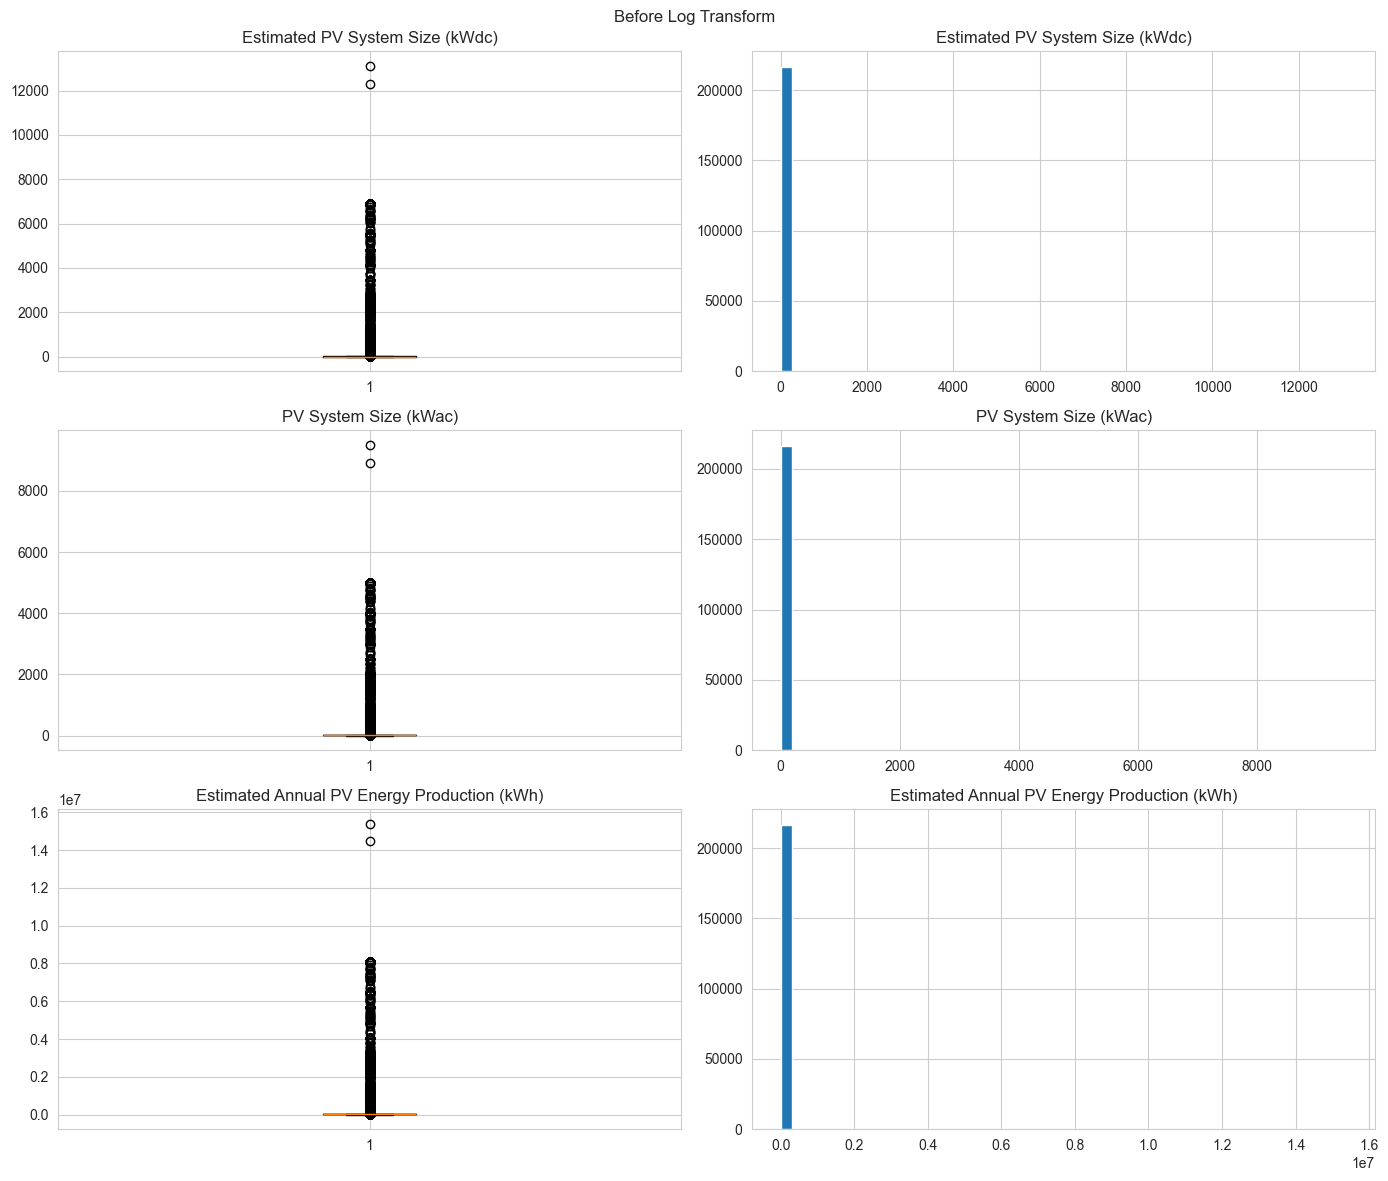

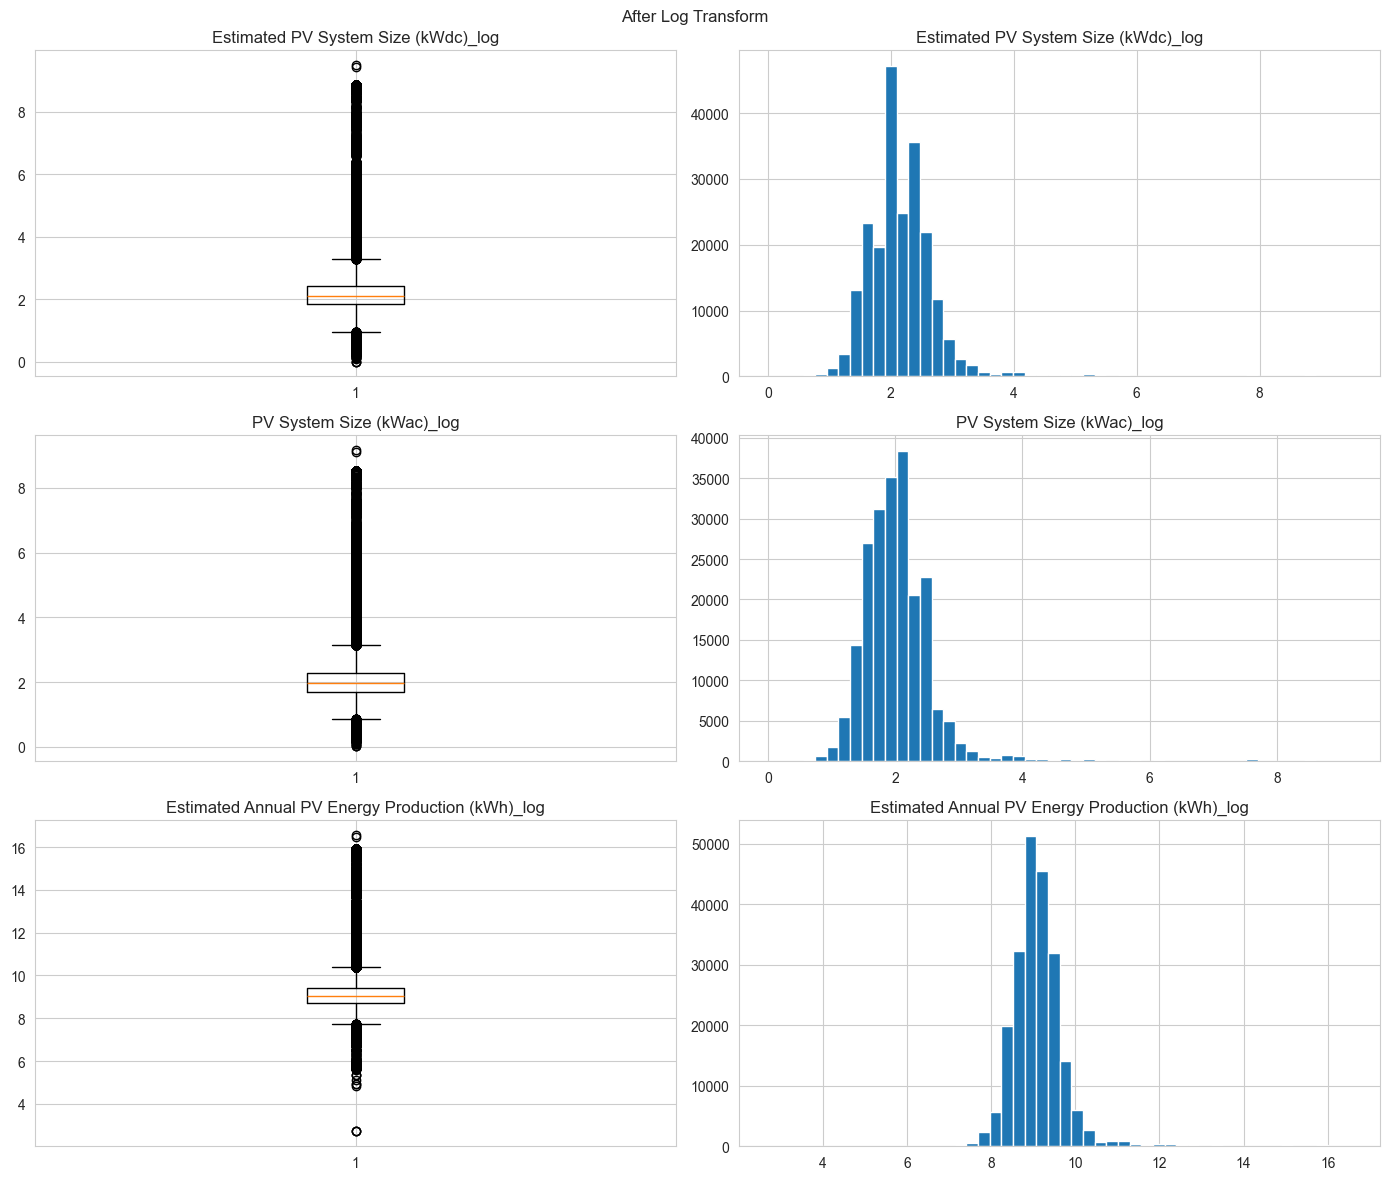

Has_Storage
0    213998
1      4087
Name: count, dtype: int64


In [6]:
num_cols = ['Estimated PV System Size (kWdc)', 'PV System Size (kWac)', 'Estimated Annual PV Energy Production (kWh)']

# check how many outliers each column has (IQR method)
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

# look before the log transform
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))
for i, col in enumerate(num_cols):
    axes[i, 0].boxplot(df[col].dropna())
    axes[i, 0].set_title(col)
    axes[i, 1].hist(df[col].dropna(), bins=50)
    axes[i, 1].set_title(col)
plt.suptitle('Before Log Transform')
plt.tight_layout()
plt.show()

# log transform: keeps the ranking (a high value stays highest), just closer together
for col in num_cols:
    df[f'{col}_log'] = np.log1p(df[col])

# look after the log transform
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))
for i, col in enumerate(num_cols):
    log_col = f'{col}_log'
    axes[i, 0].boxplot(df[log_col].dropna())
    axes[i, 0].set_title(log_col)
    axes[i, 1].hist(df[log_col].dropna(), bins=50)
    axes[i, 1].set_title(log_col)
plt.suptitle('After Log Transform')
plt.tight_layout()
plt.show()

# energy storage: separate, since most values are 0 (no battery)
storage_col = 'Energy Storage System Size (kWac)'
df['Has_Storage'] = (df[storage_col] > 0).astype(int)
non_zero = df[storage_col] > 0
df[f'{storage_col}_log'] = 0.0
df.loc[non_zero, f'{storage_col}_log'] = np.log1p(df.loc[non_zero, storage_col])

print(df['Has_Storage'].value_counts())

The IQR check flags 12,826 outliers (5.9%) in each of the three columns, most likely the same large projects, since system size and energy production go together. Before the log transform, the histograms are a single spike near zero because a few very large projects stretch the scale. After the log transform, they take a bell shape. The boxplots still show some points outside the whiskers, but that's fine: I keep them on purpose because those large projects are the high energy locations we want to find. The log transform keeps their order and only reduces the gap.

Only 4,087 of the 218,085 projects (about 1.9%) have energy storage, which is why it's handled separately.

## 5. Exploratory Data Analysis

A look at the data before clustering: how energy production is spread out, which columns move together, and which counties and developers produce the most.

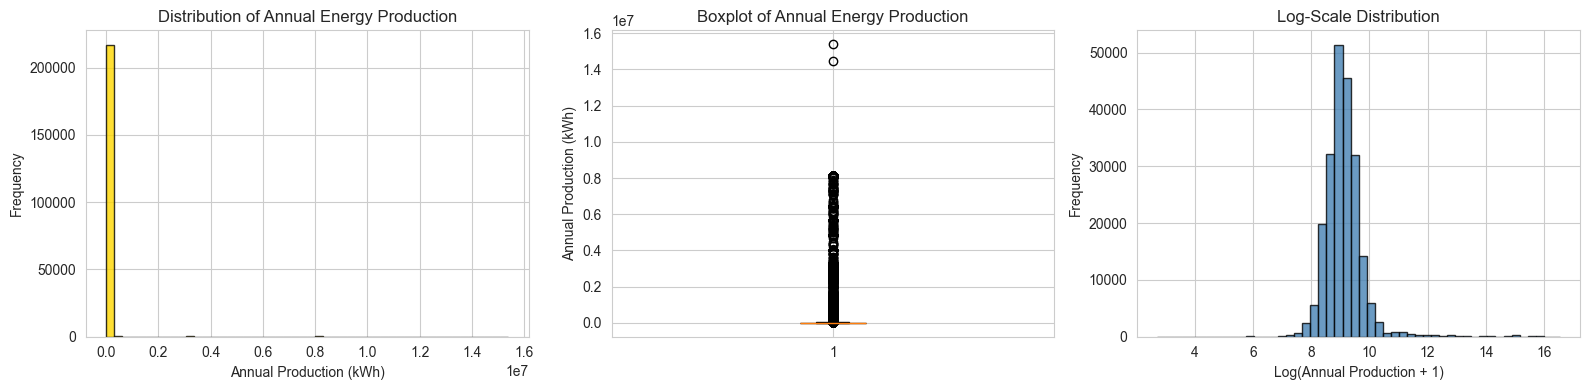

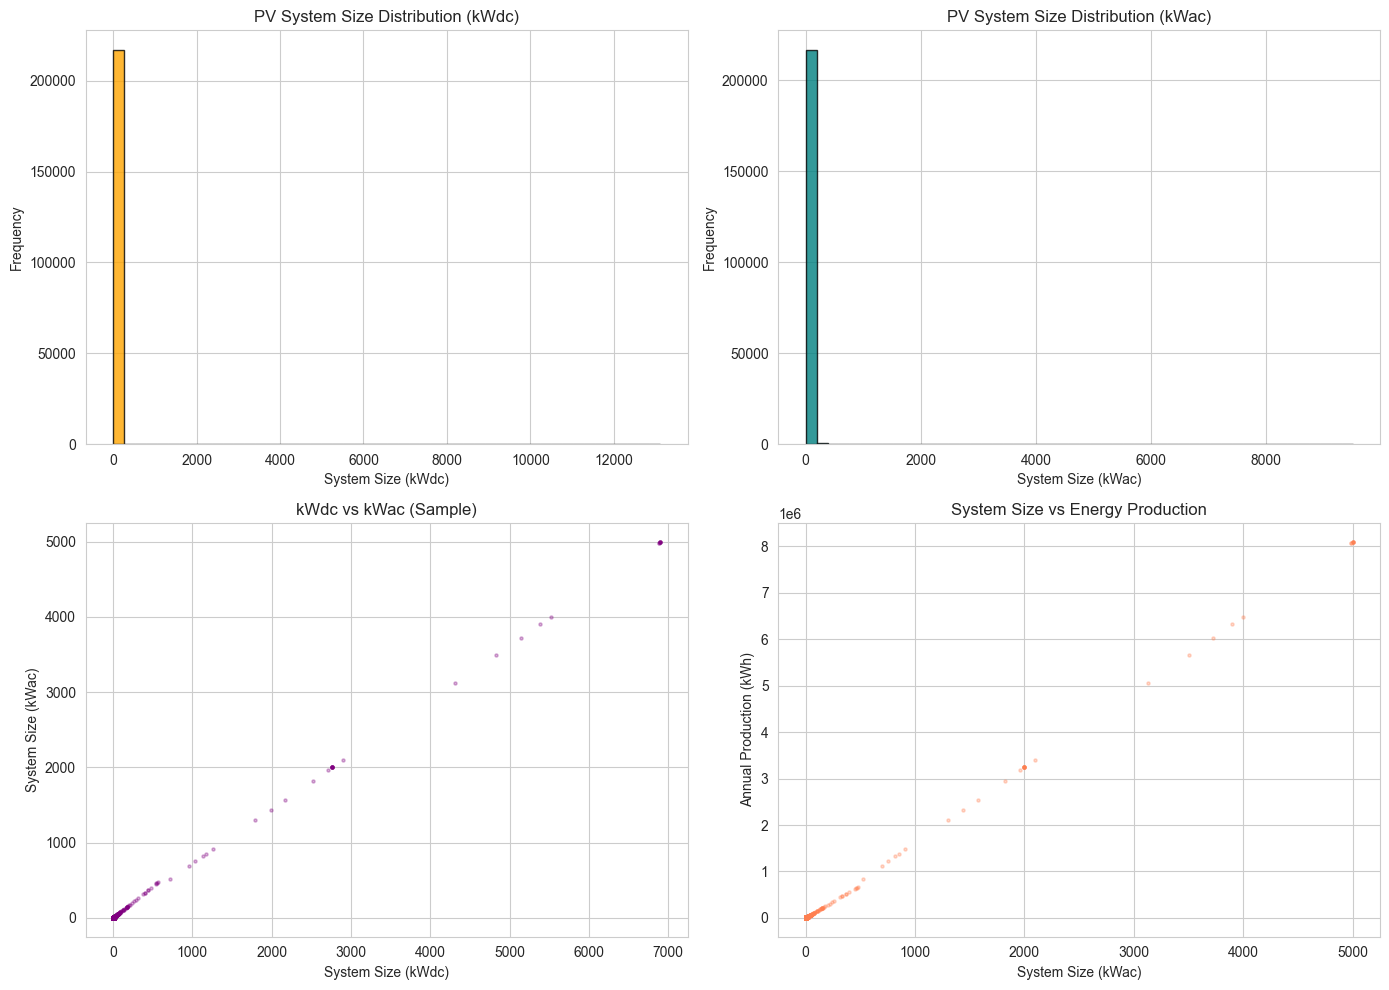

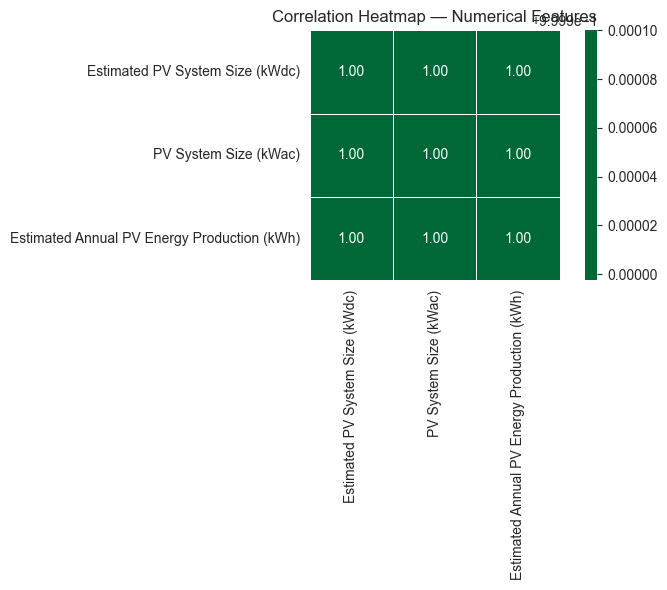

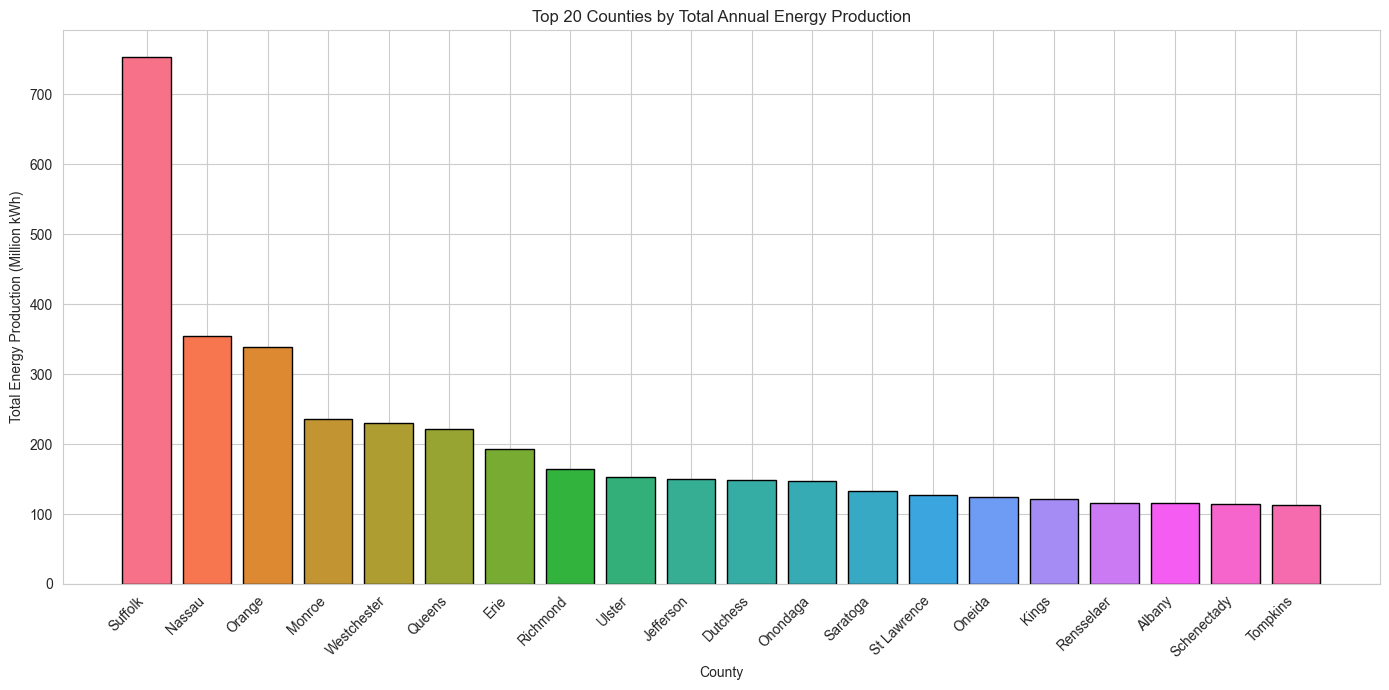

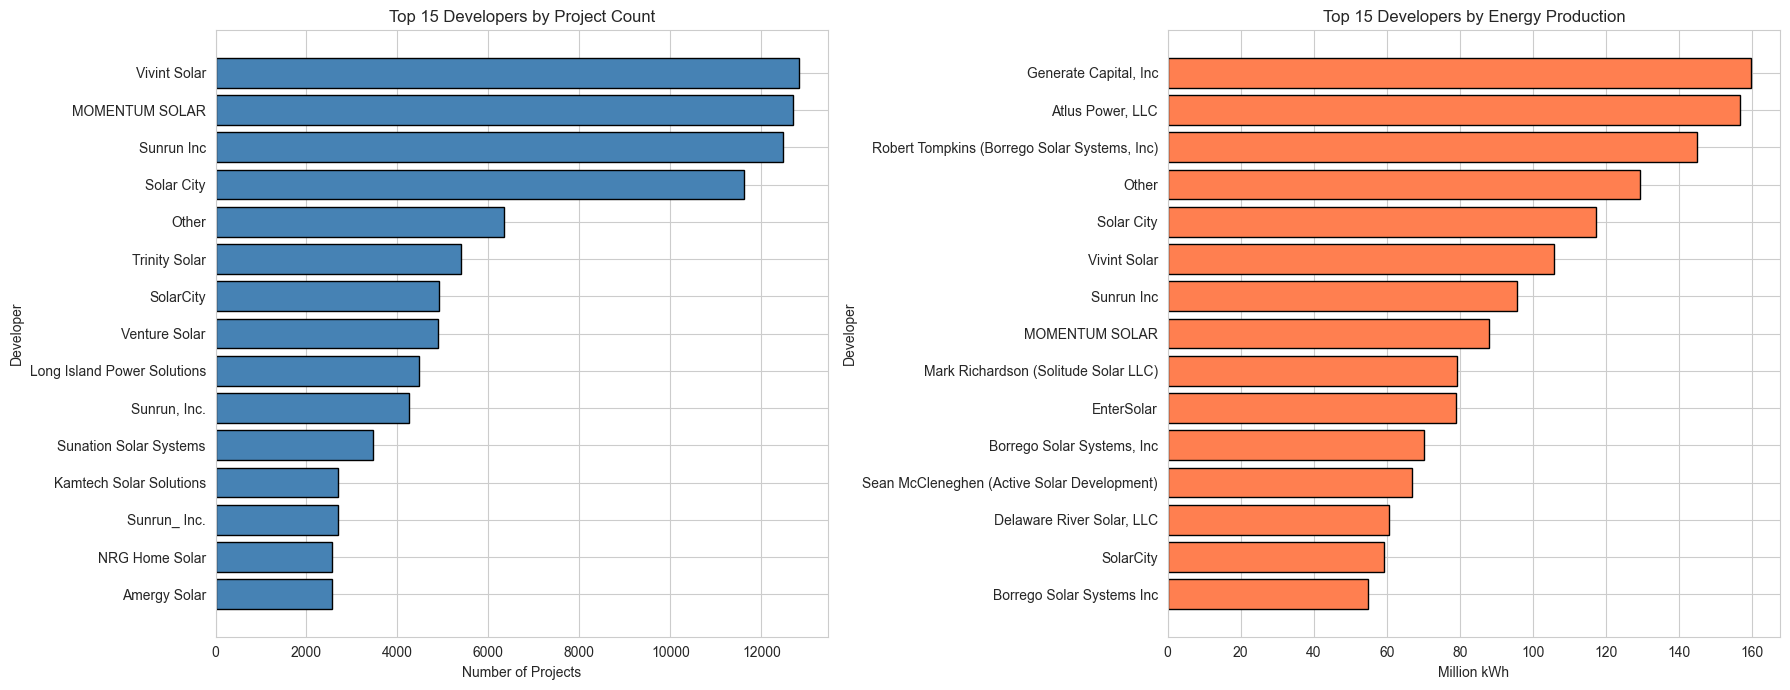

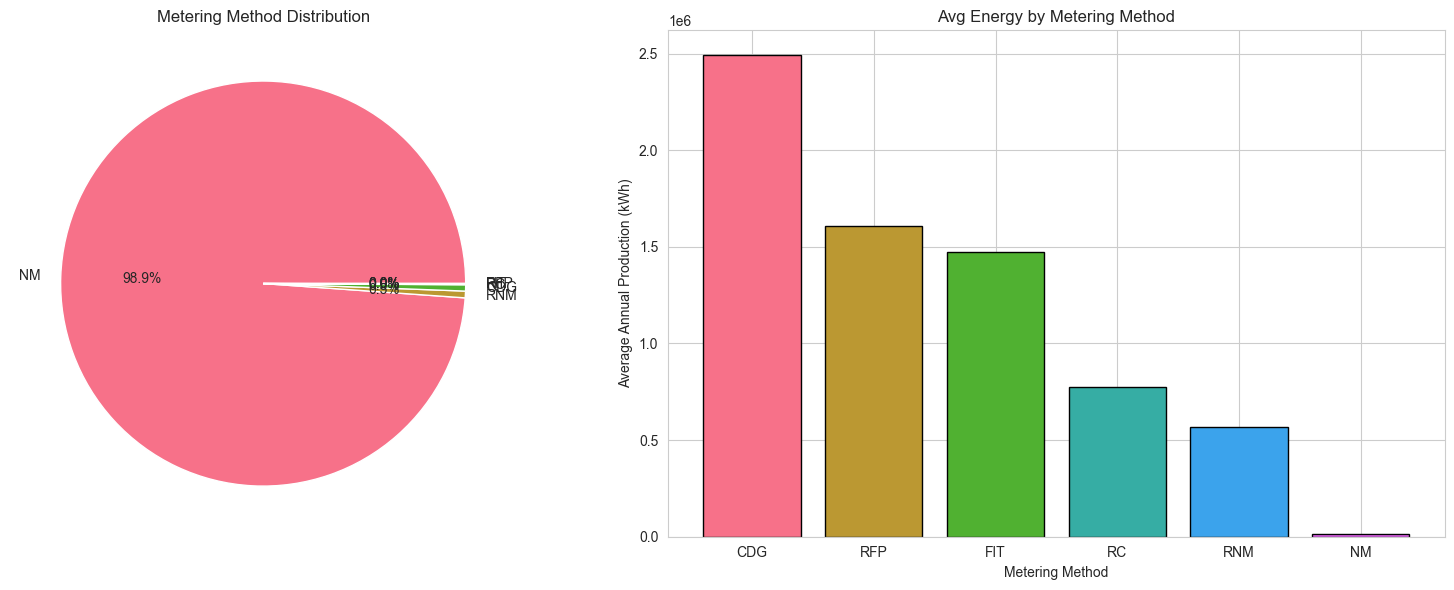

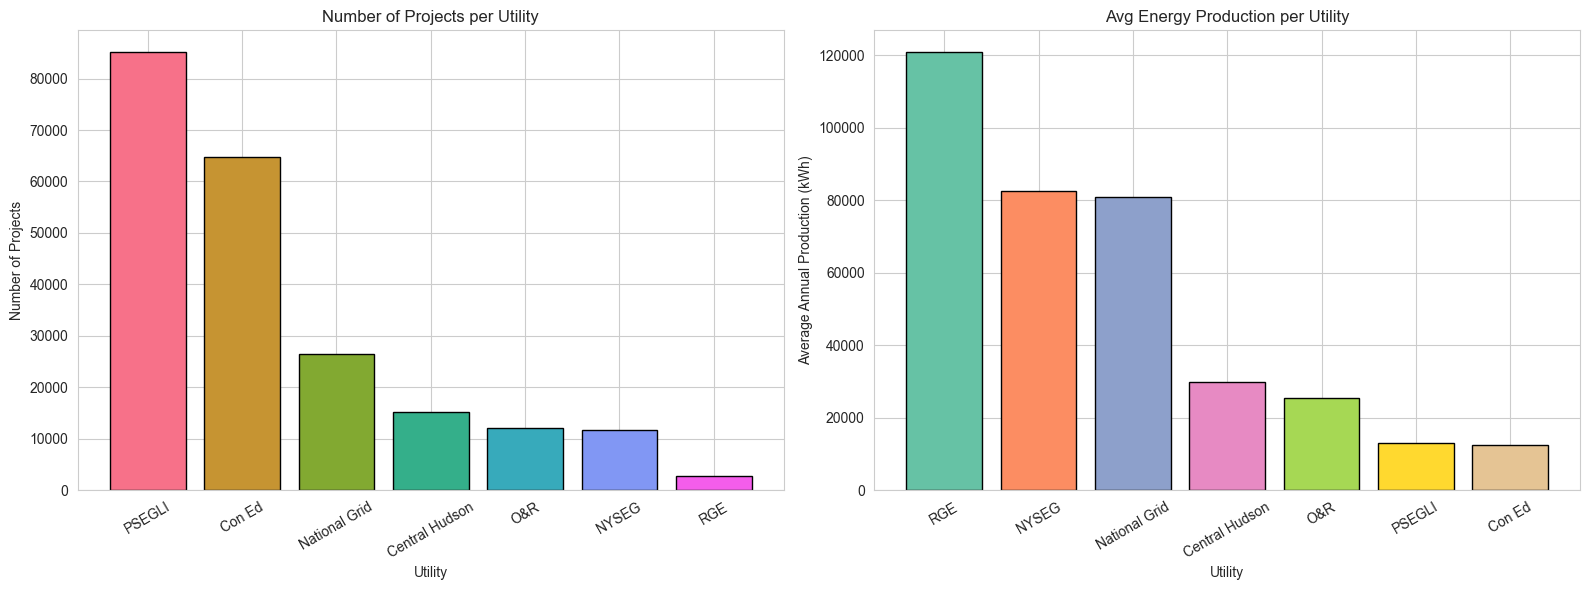

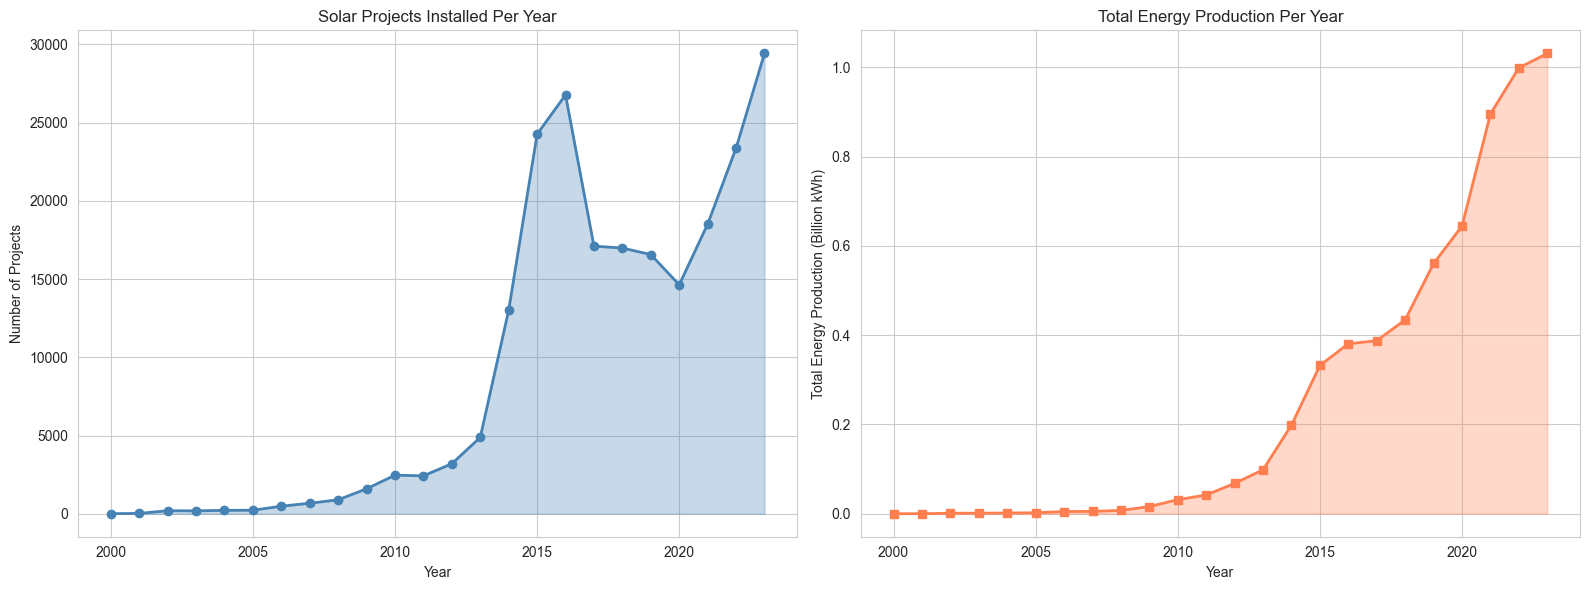

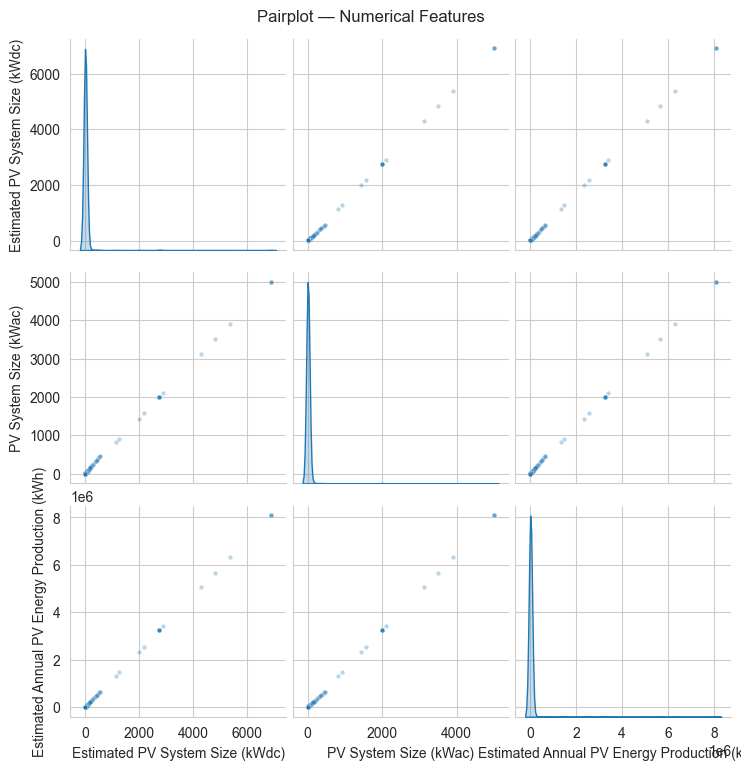

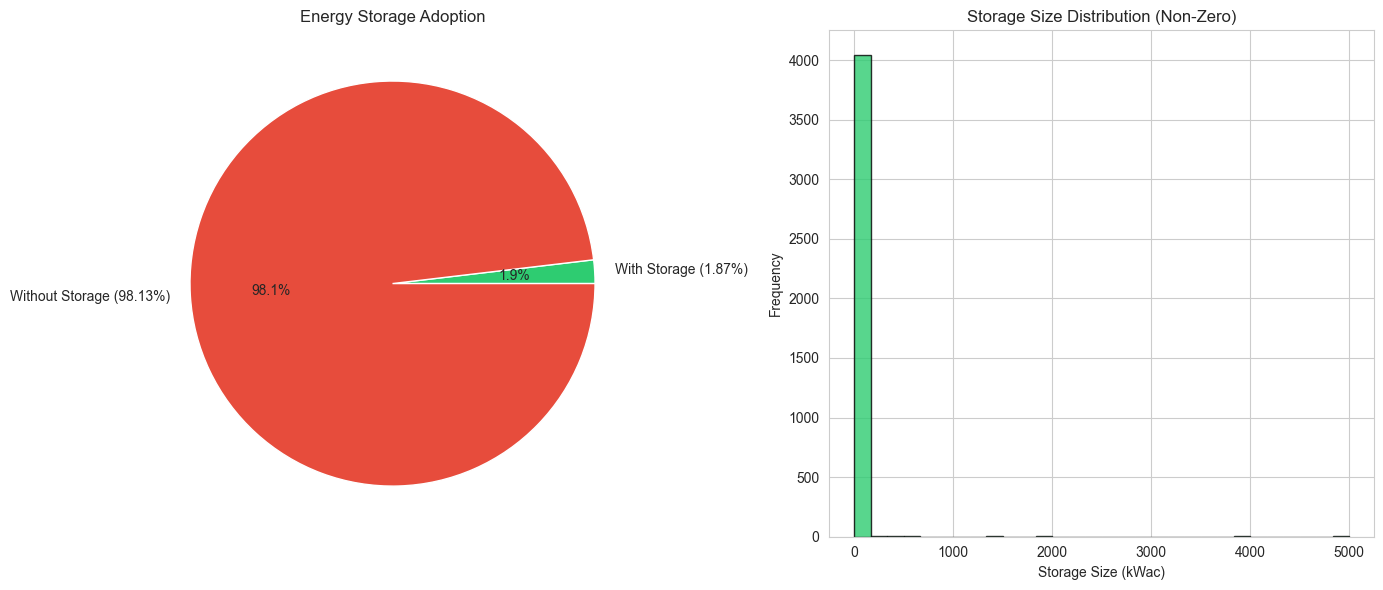

In [7]:
col = 'Estimated Annual PV Energy Production (kWh)'

# energy production distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df[col], bins=50, color='gold', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Annual Energy Production')
axes[0].set_xlabel('Annual Production (kWh)')
axes[0].set_ylabel('Frequency')
axes[1].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Boxplot of Annual Energy Production')
axes[1].set_ylabel('Annual Production (kWh)')
axes[2].hist(np.log1p(df[col]), bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[2].set_title('Log-Scale Distribution')
axes[2].set_xlabel('Log(Annual Production + 1)')
axes[2].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# system size: distributions and relationships
sample = df.sample(min(5000, len(df)), random_state=42)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(df['Estimated PV System Size (kWdc)'], bins=50, color='orange', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('PV System Size Distribution (kWdc)')
axes[0, 0].set_xlabel('System Size (kWdc)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 1].hist(df['PV System Size (kWac)'], bins=50, color='teal', edgecolor='black', alpha=0.8)
axes[0, 1].set_title('PV System Size Distribution (kWac)')
axes[0, 1].set_xlabel('System Size (kWac)')
axes[0, 1].set_ylabel('Frequency')
axes[1, 0].scatter(sample['Estimated PV System Size (kWdc)'], sample['PV System Size (kWac)'], alpha=0.3, color='purple', s=5)
axes[1, 0].set_title('kWdc vs kWac (Sample)')
axes[1, 0].set_xlabel('System Size (kWdc)')
axes[1, 0].set_ylabel('System Size (kWac)')
axes[1, 1].scatter(sample['PV System Size (kWac)'], sample[col], alpha=0.3, color='coral', s=5)
axes[1, 1].set_title('System Size vs Energy Production')
axes[1, 1].set_xlabel('System Size (kWac)')
axes[1, 1].set_ylabel('Annual Production (kWh)')
plt.tight_layout()
plt.show()

# correlation between numeric columns
num_cols = ['Estimated PV System Size (kWdc)', 'PV System Size (kWac)', col]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

# top 20 counties by total energy production
county_energy = df.groupby('County')[col].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(14, 7))
plt.bar(county_energy.index, county_energy.values / 1e6, color=sns.color_palette('husl', 20), edgecolor='black')
plt.title('Top 20 Counties by Total Annual Energy Production')
plt.xlabel('County')
plt.ylabel('Total Energy Production (Million kWh)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# top 15 developers, by project count and by energy production
df_dev = df[df['Developer'] != 'Unknown']
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
top_count = df_dev['Developer'].value_counts().head(15)
axes[0].barh(top_count.index[::-1], top_count.values[::-1], color='steelblue', edgecolor='black')
axes[0].set_title('Top 15 Developers by Project Count')
axes[0].set_xlabel('Number of Projects')
axes[0].set_ylabel('Developer')
top_energy = df_dev.groupby('Developer')[col].sum().sort_values(ascending=False).head(15)
axes[1].barh(top_energy.index[::-1], top_energy.values[::-1] / 1e6, color='coral', edgecolor='black')
axes[1].set_title('Top 15 Developers by Energy Production')
axes[1].set_xlabel('Million kWh')
axes[1].set_ylabel('Developer')
plt.tight_layout()
plt.show()

# metering method: share of projects and average energy by method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
method_counts = df['Metering Method'].value_counts()
axes[0].pie(method_counts.values, labels=method_counts.index, autopct='%1.1f%%', colors=sns.color_palette('husl', len(method_counts)))
axes[0].set_title('Metering Method Distribution')
method_energy = df.groupby('Metering Method')[col].mean().sort_values(ascending=False)
axes[1].bar(method_energy.index, method_energy.values, color=sns.color_palette('husl', len(method_energy)), edgecolor='black')
axes[1].set_title('Avg Energy by Metering Method')
axes[1].set_xlabel('Metering Method')
axes[1].set_ylabel('Average Annual Production (kWh)')
plt.tight_layout()
plt.show()

# utility: number of projects and average energy production per utility
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
utility_counts = df['Utility'].value_counts()
axes[0].bar(utility_counts.index, utility_counts.values, color=sns.color_palette('husl', len(utility_counts)), edgecolor='black')
axes[0].set_title('Number of Projects per Utility')
axes[0].set_xlabel('Utility')
axes[0].set_ylabel('Number of Projects')
axes[0].tick_params(axis='x', rotation=30)
utility_energy = df.groupby('Utility')[col].mean().sort_values(ascending=False)
axes[1].bar(utility_energy.index, utility_energy.values, color=sns.color_palette('Set2', len(utility_energy)), edgecolor='black')
axes[1].set_title('Avg Energy Production per Utility')
axes[1].set_xlabel('Utility')
axes[1].set_ylabel('Average Annual Production (kWh)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# projects and total energy production by year
df['Year'] = df['Interconnection Date'].dt.year
yearly = df.groupby('Year').agg(Projects=('Project ID', 'count'), Total_Energy=(col, 'sum')).dropna()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(yearly.index, yearly['Projects'], marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(yearly.index, yearly['Projects'], alpha=0.3, color='steelblue')
axes[0].set_title('Solar Projects Installed Per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Projects')
axes[1].plot(yearly.index, yearly['Total_Energy'] / 1e9, marker='s', color='coral', linewidth=2)
axes[1].fill_between(yearly.index, yearly['Total_Energy'] / 1e9, alpha=0.3, color='coral')
axes[1].set_title('Total Energy Production Per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Energy Production (Billion kWh)')
plt.tight_layout()
plt.show()

# pairplot of the main numeric columns
sample_pp = df[num_cols].sample(min(3000, len(df)), random_state=42)
pp = sns.pairplot(sample_pp, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
pp.fig.suptitle('Pairplot — Numerical Features', y=1.02)
plt.show()

# energy storage adoption
storage_col = 'Energy Storage System Size (kWac)'
has_storage = (df[storage_col] > 0).sum()
no_storage = (df[storage_col] == 0).sum()
pct = round(has_storage / len(df) * 100, 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie([has_storage, no_storage], labels=[f'With Storage ({pct}%)', f'Without Storage ({100 - pct}%)'], colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%')
axes[0].set_title('Energy Storage Adoption')
storage_data = df[df[storage_col] > 0][storage_col]
axes[1].hist(storage_data, bins=30, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].set_title('Storage Size Distribution (Non-Zero)')
axes[1].set_xlabel('Storage Size (kWac)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

Add coordinates to each project using the ZIP code table, then group the projects by location (County + City/Town + Zip), since the goal is to cluster locations, not individual projects.

Each location is described by 4 numbers: total kWh, kWac, kWdc and number of projects. Total_Storage is left out because most of it is 0, so it can't tell locations apart. These features are then scaled, checked for overlap with a correlation heatmap, and reduced with PCA if they overlap.

218082 / 218085 rows matched to coordinates
2500 unique locations


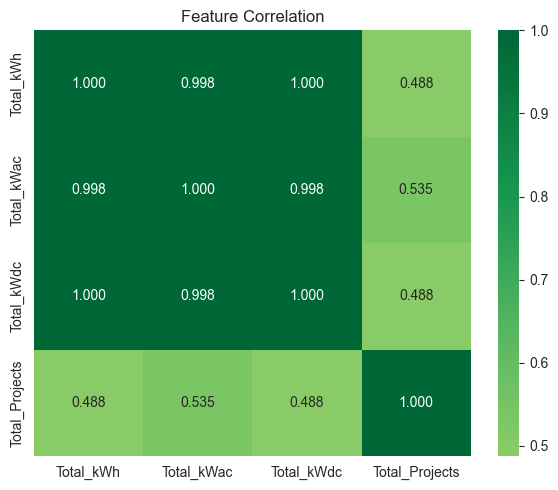

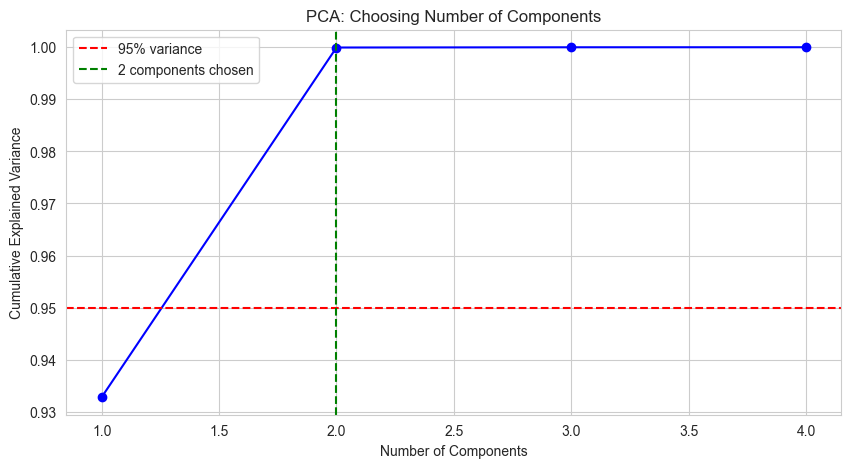

Reduced from 4 features to 2 components, keeping 100.0% of the variance


In [8]:
# add coordinates to each project
df['Zip'] = df['Zip'].str.strip()
zip_latlong['Zip'] = zip_latlong['Zip'].astype(str).str.strip()
df = df.merge(zip_latlong[['Zip', 'Latitude', 'Longitude']], on='Zip', how='left')
print(df['Latitude'].notna().sum(), '/', len(df), 'rows matched to coordinates')

# group projects by location, since we cluster locations not individual projects
agg_df = df.groupby(['County', 'City/Town', 'Zip']).agg(
    Total_kWdc=('Estimated PV System Size (kWdc)', 'sum'),
    Total_kWac=('PV System Size (kWac)', 'sum'),
    Total_kWh=('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Avg_kWh=('Estimated Annual PV Energy Production (kWh)', 'mean'),
    Total_Projects=('Number of Projects', 'sum'),
    Total_Storage=('Energy Storage System Size (kWac)', 'sum'),
    Latitude=('Latitude', 'mean'),
    Longitude=('Longitude', 'mean'),
    Unique_Developers=('Developer', 'nunique'),
    Utility=('Utility', lambda x: x.mode()[0])
).reset_index()
print(len(agg_df), 'unique locations')

# features for clustering (Total_Storage excluded: mostly zeros, no variation)
feature_cols = ['Total_kWh', 'Total_kWac', 'Total_kWdc', 'Total_Projects']
X = np.log1p(agg_df[feature_cols].fillna(0))
X_scaled = StandardScaler().fit_transform(X)

# check correlation between the features
plt.figure(figsize=(6, 5))
sns.heatmap(agg_df[feature_cols].corr(), annot=True, fmt='.3f', cmap='RdYlGn', center=0)
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

# PCA: find how many components keep 95% of the variance
pca_check = PCA(random_state=42).fit(X_scaled)
cum_var = np.cumsum(pca_check.explained_variance_ratio_)
n_comp = int(np.searchsorted(cum_var, 0.95) + 1)

plt.plot(range(1, len(cum_var) + 1), cum_var, 'bo-')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.axvline(n_comp, color='green', linestyle='--', label=f'{n_comp} components chosen')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.title('PCA: Choosing Number of Components')
plt.show()

pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Reduced from {X_scaled.shape[1]} features to {n_comp} components, keeping {sum(pca.explained_variance_ratio_):.1%} of the variance')

218,082 of the 218,085 projects matched to coordinates, and grouping them gave 2,500 unique locations.

The heatmap shows that total kWh, kWac and kWdc are almost perfectly correlated (0.998 to 1.000), because they all measure system size in different units. Total_Projects is less correlated with them (about 0.49 to 0.54). Using all 4 features as they are would count "size" three times, so PCA combines them into 2 components that keep 100% of the variance.

## 7. Finding the Optimal Number of Clusters (K)

Before clustering, we need to decide how many clusters (K) to use. This section checks 4 methods, Elbow, Silhouette, Davies-Bouldin, and Calinski-Harabasz, across K = 2 to 12 to see what they suggest.

Silhouette vote: 2
Davies-Bouldin vote: 2
Calinski-Harabasz vote: 9


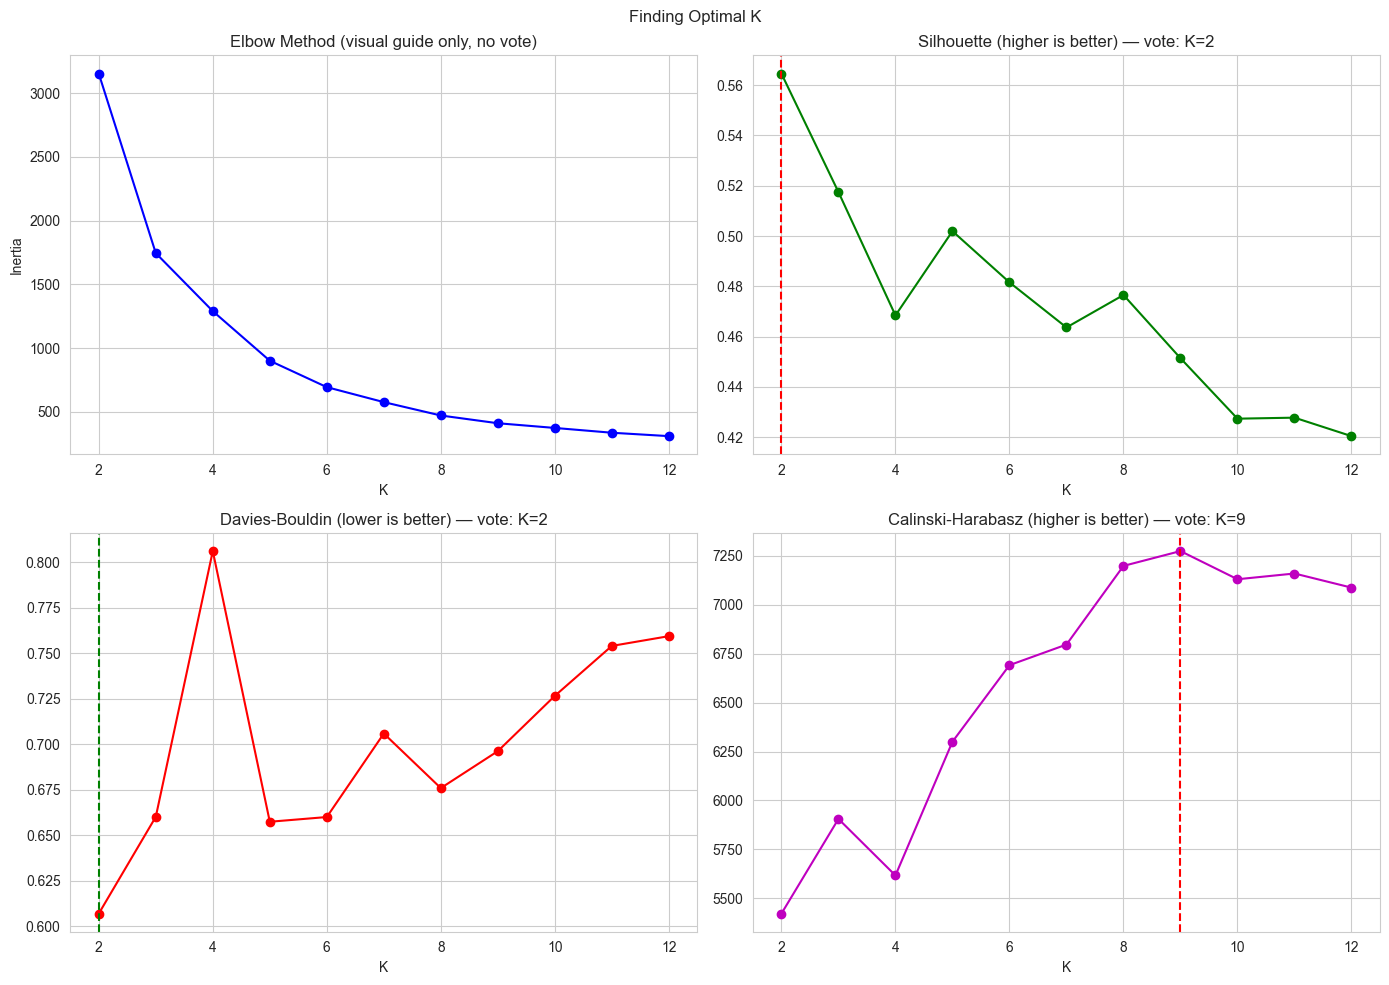

In [9]:
k_range = list(range(2, 13))
inertias, sil_scores, db_scores, ch_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

best_sil_k = k_range[np.argmax(sil_scores)]
best_db_k = k_range[np.argmin(db_scores)]
best_ch_k = k_range[np.argmax(ch_scores)]

print('Silhouette vote:', best_sil_k)
print('Davies-Bouldin vote:', best_db_k)
print('Calinski-Harabasz vote:', best_ch_k)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(k_range, inertias, 'bo-')
axes[0, 0].set_title('Elbow Method (visual guide only, no vote)')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(k_range, sil_scores, 'go-')
axes[0, 1].axvline(best_sil_k, color='red', linestyle='--')
axes[0, 1].set_title(f'Silhouette (higher is better) — vote: K={best_sil_k}')
axes[0, 1].set_xlabel('K')

axes[1, 0].plot(k_range, db_scores, 'ro-')
axes[1, 0].axvline(best_db_k, color='green', linestyle='--')
axes[1, 0].set_title(f'Davies-Bouldin (lower is better) — vote: K={best_db_k}')
axes[1, 0].set_xlabel('K')

axes[1, 1].plot(k_range, ch_scores, 'mo-')
axes[1, 1].axvline(best_ch_k, color='red', linestyle='--')
axes[1, 1].set_title(f'Calinski-Harabasz (higher is better) — vote: K={best_ch_k}')
axes[1, 1].set_xlabel('K')

plt.suptitle('Finding Optimal K')
plt.tight_layout()
plt.show()

The 4 methods don't agree. Silhouette and Davies-Bouldin both pick K=2, which only splits the locations into "big vs small". Calinski-Harabasz picks K=9, but that metric tends to favor higher K by how its formula works. The elbow curve has no sharp bend: the biggest drop in inertia is from K=2 to K=3, and after about K=4 to 5 the curve flattens.

I'm choosing K=3 manually. The business goal is High, Medium and Low energy zones, and K=3 fits that. It also holds up on the numbers: inertia drops sharply going from K=2 to K=3, and the Silhouette score at K=3 (about 0.52) is still among the highest, only slightly below K=2 (about 0.56).

In [10]:
optimal_k = 3

final_km = KMeans(n_clusters=optimal_k, init='k-means++', n_init='auto', random_state=42)
labels = final_km.fit_predict(X_pca)

print('Chosen K:', optimal_k)
print('Cluster sizes:', pd.Series(labels).value_counts().sort_index().to_dict())

Chosen K: 3
Cluster sizes: {0: 851, 1: 765, 2: 884}


The 2,500 locations split into 3 clusters of similar size: 851, 765 and 884 locations. No cluster is tiny or dominates, so all three are usable. The labels 0, 1 and 2 are only cluster numbers, not names yet. I'll check the average energy production of each cluster in the cluster analysis phase to see which one is High, Medium and Low.

## 8. Silhouette Check for K = 3 to 5

The average silhouette score gives one number per K. These plots show the silhouette score of every location, grouped by cluster, for K = 3, 4 and 5, to compare how well formed the clusters are.

K=3, cluster 0: average 0.640, 0 of 851 locations below 0
K=3, cluster 1: average 0.434, 30 of 765 locations below 0
K=3, cluster 2: average 0.472, 13 of 884 locations below 0
K=4, cluster 0: average 0.643, 0 of 705 locations below 0
K=4, cluster 1: average 0.294, 40 of 596 locations below 0
K=4, cluster 2: average 0.479, 4 of 693 locations below 0
K=4, cluster 3: average 0.416, 0 of 506 locations below 0
K=5, cluster 0: average 0.661, 0 of 658 locations below 0
K=5, cluster 1: average 0.486, 0 of 541 locations below 0
K=5, cluster 2: average 0.436, 9 of 661 locations below 0
K=5, cluster 3: average 0.423, 13 of 469 locations below 0
K=5, cluster 4: average 0.410, 4 of 171 locations below 0


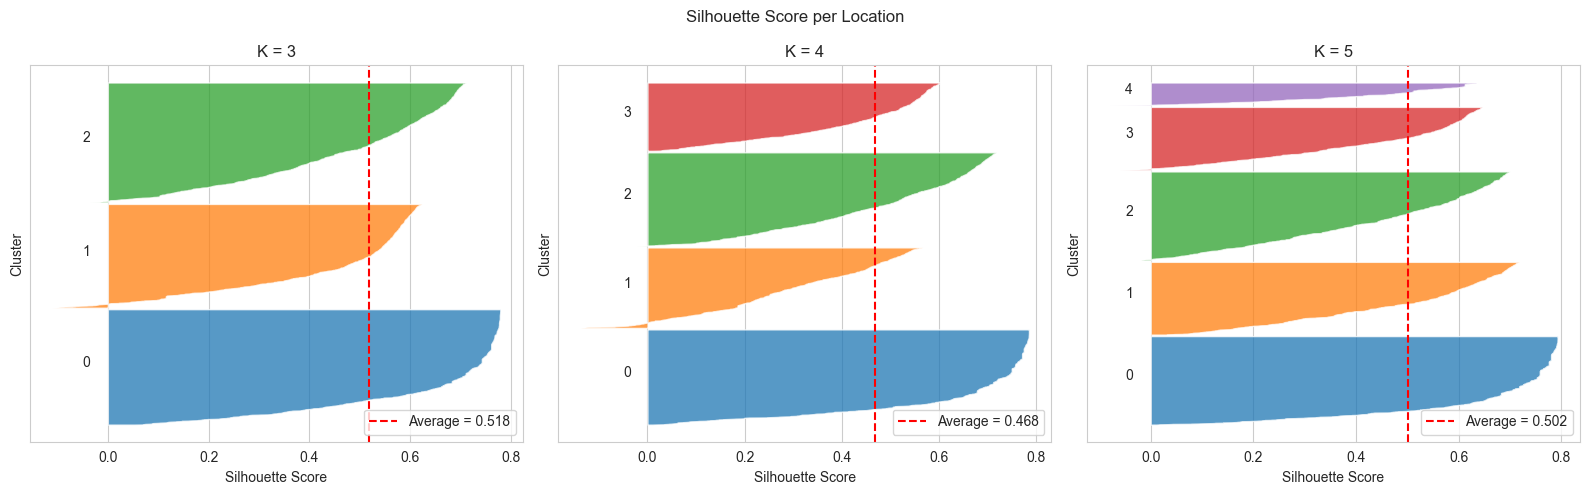

In [11]:
from sklearn.metrics import silhouette_samples

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, k in zip(axes, [3, 4, 5]):
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    k_labels = km.fit_predict(X_pca)
    sil_values = silhouette_samples(X_pca, k_labels)

    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(sil_values[k_labels == i])
        y_upper = y_lower + len(cluster_vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals, alpha=0.75)
        ax.text(-0.05, y_lower + 0.5 * len(cluster_vals), str(i))
        y_lower = y_upper + 10
        print(f'K={k}, cluster {i}: average {cluster_vals.mean():.3f}, {(cluster_vals < 0).sum()} of {len(cluster_vals)} locations below 0')

    ax.axvline(sil_values.mean(), color='red', linestyle='--', label=f'Average = {sil_values.mean():.3f}')
    ax.set_title(f'K = {k}')
    ax.set_xlabel('Silhouette Score')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.legend()

plt.suptitle('Silhouette Score per Location')
plt.tight_layout()
plt.show()

K=3 has the highest average silhouette score (0.518) of the three, and its largest cluster (cluster 0, 851 locations) is very clean, with an average of 0.640 and no location below 0. The other two clusters are weaker, around 0.43 to 0.47, with 30 and 13 locations scoring below 0.

K=4 is the weakest of the three (average 0.468), mainly because of cluster 1, which has a low average (0.294) and 40 locations below 0, the worst of any cluster at any K tested.

K=5 has the most even clusters, none scoring below an average of 0.41, and fewer locations below 0 overall (26, versus 43 at K=3). But it splits the data into 5 groups instead of 3, which is harder to act on as High/Medium/Low.

This supports keeping K=3. It has the best average score, and one strong, clearly separated cluster. K=4 is worse on every measure here, so there's no reason to consider it. K=5 forms slightly cleaner clusters, but at the cost of more zones than the business needs.

## 9. Model Building & Comparison

Train 4 different clustering algorithms on the same PCA-reduced data (K-Means, DBSCAN, Hierarchical, GMM), so they can be compared fairly in the next phase. K-Means, Hierarchical and GMM all use K=3. DBSCAN doesn't take a K, it needs an `eps` value instead (how close points must be to count as neighbors), which is tuned separately below before training.

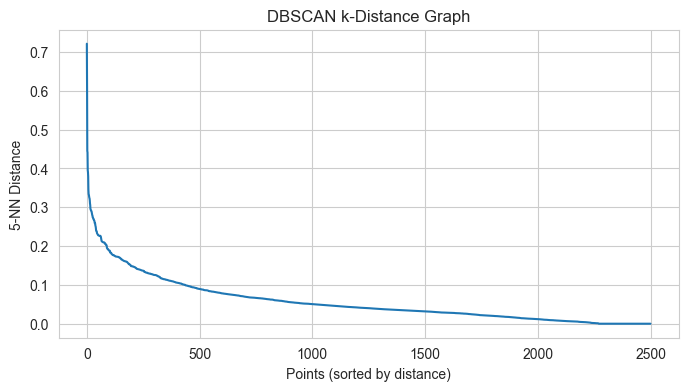

Knee-based eps: 0.22642168632075893
eps=0.1: clusters=21, noise=320
eps=0.15: clusters=14, noise=117
eps=0.2: clusters=9, noise=47
eps=0.25: clusters=2, noise=16


In [12]:
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

# k-distance graph
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
kth_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(kth_dist)
plt.title('DBSCAN k-Distance Graph')
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'{min_samples}-NN Distance')
plt.show()

# find the knee point properly, instead of guessing
kneedle = KneeLocator(range(len(kth_dist)), kth_dist, curve='convex', direction='decreasing')
eps = kth_dist[kneedle.elbow]
print('Knee-based eps:', eps)

# test a few eps values around it, to see how sensitive the result is
for test_eps in [0.1, 0.15, 0.2, 0.25]:
    test_labels = DBSCAN(eps=test_eps, min_samples=min_samples).fit_predict(X_pca)
    n_clusters = len(set(test_labels)) - (1 if -1 in test_labels else 0)
    n_noise = (test_labels == -1).sum()
    print(f'eps={test_eps}: clusters={n_clusters}, noise={n_noise}')

The knee-based eps is used for DBSCAN below. The `kneed` library finds the knee at eps=0.226. The grid search shows a clear trade-off: smaller eps means more clusters and more noise points (eps=0.1 gives 21 clusters, 320 noise points), while larger eps means fewer clusters and less noise (eps=0.25 gives just 2 clusters, 16 noise points). The knee-based eps (0.226) sits between the eps=0.2 and eps=0.25 results, so it should land somewhere around 2 to 9 clusters, not a clean match for K=3. That's expected: DBSCAN decides the cluster count from density, it doesn't take a fixed K like the other algorithms.

KMeans clusters: [0 1 2] inertia: 1745.13
DBSCAN (eps=0.226) clusters: 6, noise: 22 (0.9%)


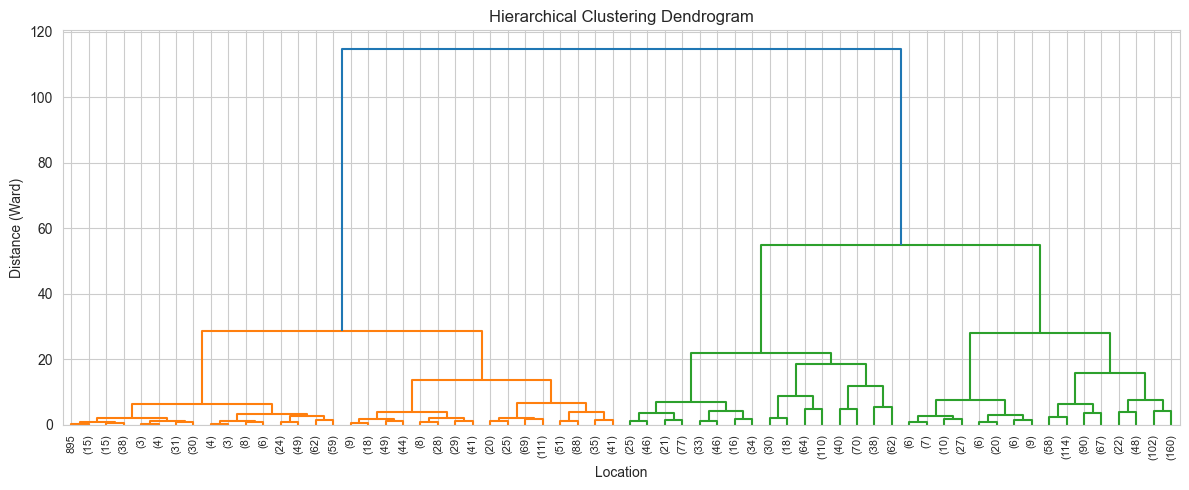

Hierarchical clusters: [0 1 2]
GMM clusters: [0 1 2] BIC: 10060.31 AIC: 9961.3


In [13]:
# K-Means
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init='auto', random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_pca)
print('KMeans clusters:', np.unique(kmeans_labels), 'inertia:', round(kmeans_model.inertia_, 2))

# DBSCAN (eps from the exploration cell)
dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan_model.fit_predict(X_pca)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f'DBSCAN (eps={eps:.3f}) clusters: {n_clusters}, noise: {n_noise} ({n_noise / len(dbscan_labels) * 100:.1f}%)')

# Hierarchical, full data
linked = linkage(X_pca, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=5, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Location')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

hierarchical_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(X_pca)
print('Hierarchical clusters:', np.unique(hierarchical_labels))

# GMM
gmm_model = GaussianMixture(n_components=optimal_k, init_params='k-means++', n_init=1, random_state=42)
gmm_model.fit(X_pca)
gmm_labels = gmm_model.predict(X_pca)
print('GMM clusters:', np.unique(gmm_labels), 'BIC:', round(gmm_model.bic(X_pca), 2), 'AIC:', round(gmm_model.aic(X_pca), 2))

K-Means and GMM both produced 3 clusters as set. K-Means has an inertia of 1745.13, and GMM has a BIC of 10060.31 and AIC of 9961.30. The dendrogram shows two very distinct top-level branches, with one noticeably larger than the other, and cutting it at K=3 also gives 3 clusters.

DBSCAN, with the tuned eps=0.226, found 6 clusters and marked 22 locations (0.9%) as noise, not 3. This is expected, since DBSCAN decides the cluster count from density rather than a fixed K. It's included in the comparison as-is in the next phase, since forcing it to produce exactly 3 clusters would mean picking an eps that doesn't reflect what the density tuning actually found.

## 10. Model Evaluation & Selection

Score all 4 models (K-Means, DBSCAN, Hierarchical, GMM) using the same 3 metrics from Phase 7, then pick the best one. Silhouette and Davies-Bouldin count double, since they're the more reliable metrics; Calinski-Harabasz counts once, since it tends to favor models with more clusters. DBSCAN's noise points are excluded before scoring, since they aren't part of any real cluster.

          Model  Silhouette  Davies-Bouldin  Calinski-Harabasz  N_Clusters  \
0        KMeans      0.5175          0.6602            5905.66           3   
1        DBSCAN     -0.0132          0.9397              27.30           6   
2  Hierarchical      0.4895          0.7479            5277.27           3   
3           GMM      0.2321          1.2887            1473.64           3   

   N_Noise  
0        0  
1       22  
2        0  
3        0  


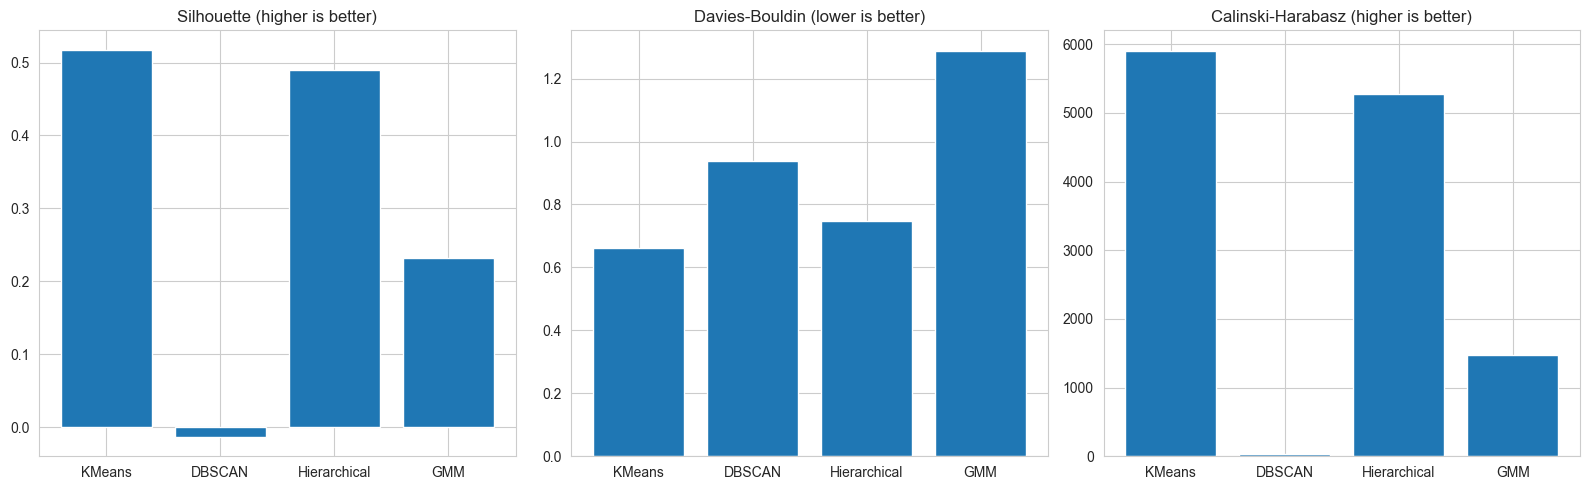

Scores: {'KMeans': 5, 'DBSCAN': 0, 'Hierarchical': 0, 'GMM': 0}
Best model: KMeans


In [14]:
results = {
    'KMeans': kmeans_labels,
    'DBSCAN': dbscan_labels,
    'Hierarchical': hierarchical_labels,
    'GMM': gmm_labels,
}

eval_rows = []
for name, model_labels in results.items():
    valid = model_labels != -1
    sil = silhouette_score(X_pca[valid], model_labels[valid])
    db = davies_bouldin_score(X_pca[valid], model_labels[valid])
    ch = calinski_harabasz_score(X_pca[valid], model_labels[valid])
    eval_rows.append({
        'Model': name,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(db, 4),
        'Calinski-Harabasz': round(ch, 2),
        'N_Clusters': len(np.unique(model_labels[valid])),
        'N_Noise': int((model_labels == -1).sum())
    })

comparison_df = pd.DataFrame(eval_rows)
print(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(comparison_df['Model'], comparison_df['Silhouette'])
axes[0].set_title('Silhouette (higher is better)')
axes[1].bar(comparison_df['Model'], comparison_df['Davies-Bouldin'])
axes[1].set_title('Davies-Bouldin (lower is better)')
axes[2].bar(comparison_df['Model'], comparison_df['Calinski-Harabasz'])
axes[2].set_title('Calinski-Harabasz (higher is better)')
plt.tight_layout()
plt.show()

# score: Silhouette and Davies-Bouldin count double (more reliable),
# Calinski-Harabasz counts once (it tends to favor more clusters)
scores = {name: 0 for name in comparison_df['Model']}
scores[comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Model']] += 2
scores[comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin(), 'Model']] += 2
scores[comparison_df.loc[comparison_df['Calinski-Harabasz'].idxmax(), 'Model']] += 1

best_name = max(scores, key=scores.get)
print('Scores:', scores)
print('Best model:', best_name)

best_labels = results[best_name]

K-Means wins clearly, with the best score on all 3 metrics (Silhouette 0.518, Davies-Bouldin 0.660, Calinski-Harabasz 5905.66), for a total of 5 points, the other 3 models scored 0.

Hierarchical is close behind on Silhouette (0.490) and Calinski-Harabasz (5277.27), but doesn't beat K-Means on any metric. GMM is noticeably weaker on all 3 (Silhouette 0.232, Davies-Bouldin 1.289). DBSCAN performs the worst here: its Silhouette score is negative (-0.013), meaning many of its 6 clusters overlap more than they separate, and its Calinski-Harabasz score (27.30) is far below the other 3 models, this matches what we saw earlier: DBSCAN isn't well suited to this data's density pattern.

**K-Means is the chosen model**, confirming the clustering already built and used in the earlier phases.

## 11. Stability Check

K-Means depends on where it starts (the initial centroids), so before trusting the K=3 clustering, I check if the result stays the same across different random seeds. If the clusters come out consistent every time, the result is reliable, not just a product of one lucky run.

In [15]:
seeds = [0, 1, 2, 42, 100]
sil_by_seed = []

for seed in seeds:
    km = KMeans(n_clusters=optimal_k, init='k-means++', n_init='auto', random_state=seed)
    seed_labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, seed_labels)
    sil_by_seed.append(sil)
    print(f'seed={seed}: silhouette={sil:.4f}, cluster sizes={pd.Series(seed_labels).value_counts().sort_index().to_dict()}')

print('\nSilhouette range across seeds:', round(min(sil_by_seed), 4), 'to', round(max(sil_by_seed), 4))

seed=0: silhouette=0.5175, cluster sizes={0: 885, 1: 876, 2: 739}
seed=1: silhouette=0.5175, cluster sizes={0: 765, 1: 884, 2: 851}
seed=2: silhouette=0.5175, cluster sizes={0: 739, 1: 876, 2: 885}
seed=42: silhouette=0.5175, cluster sizes={0: 851, 1: 765, 2: 884}
seed=100: silhouette=0.5175, cluster sizes={0: 884, 1: 765, 2: 851}

Silhouette range across seeds: 0.5175 to 0.5175


The silhouette score is exactly 0.5175 for every seed, and the cluster sizes are the same 3 groups each time (765, 851, and 884 locations), just numbered differently depending on the seed. This confirms the K=3 clustering is stable: it isn't the result of one lucky random start, it converges to the same solution regardless of the seed.

## 12. Cluster Analysis & Visualization

Label the 3 clusters as High, Medium, and Low Energy Zones, based on their average energy production, then look at what each zone looks like: where it sits in the PCA space, what its features look like, and how its energy production compares to the others.

   Cluster       Avg_kWh   Total_kWh  Total_Projects  N_Locations
1        1  7.489440e+06  5729421492          195958          765
2        2  4.440786e+05   392565519           20241          884
0        0  2.503084e+04    21301249            1886          851
High Energy Zone: 765 locations, avg 7,489,440 kWh/yr, total 5,729,421,492 kWh/yr
Medium Energy Zone: 884 locations, avg 444,079 kWh/yr, total 392,565,519 kWh/yr
Low Energy Zone: 851 locations, avg 25,031 kWh/yr, total 21,301,249 kWh/yr


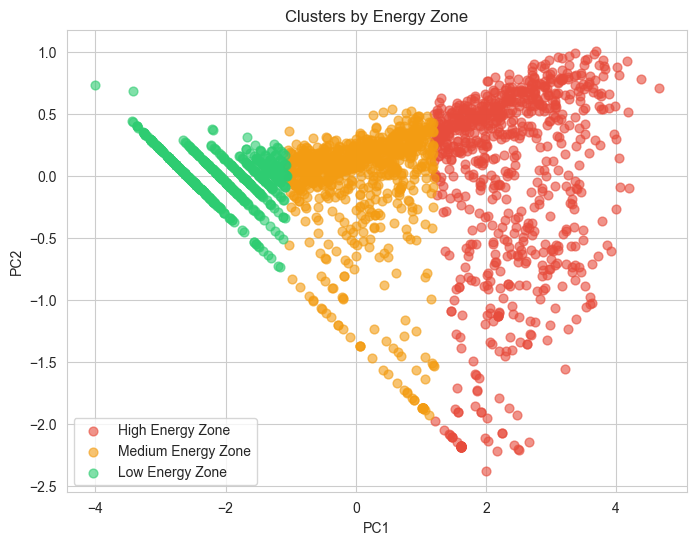

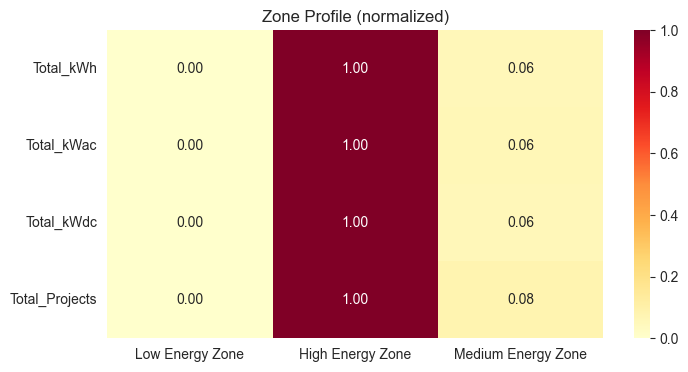

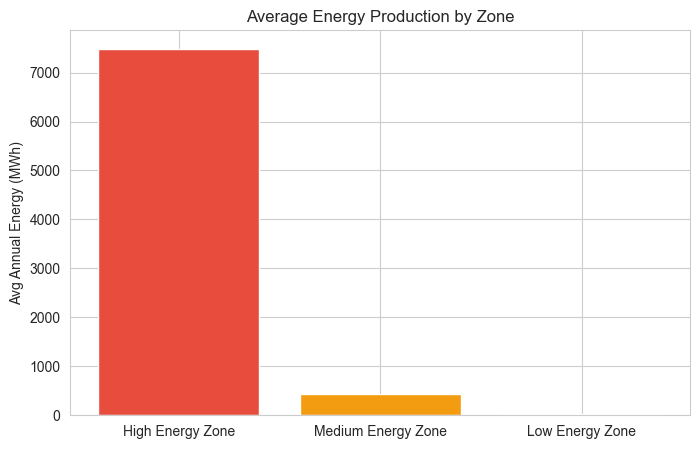

In [16]:
agg_df['Cluster'] = best_labels

cluster_summary = agg_df.groupby('Cluster').agg(
    Avg_kWh=('Total_kWh', 'mean'),
    Total_kWh=('Total_kWh', 'sum'),
    Total_Projects=('Total_Projects', 'sum'),
    N_Locations=('County', 'count')
).reset_index()
print(cluster_summary.sort_values('Avg_kWh', ascending=False))

# name the clusters by energy rank: highest = High, lowest = Low, middle = Medium
sorted_clusters = cluster_summary.sort_values('Avg_kWh', ascending=False)['Cluster'].tolist()
zone_names = {sorted_clusters[0]: 'High Energy Zone', sorted_clusters[1]: 'Medium Energy Zone', sorted_clusters[2]: 'Low Energy Zone'}
zone_colors = {sorted_clusters[0]: '#e74c3c', sorted_clusters[1]: '#f39c12', sorted_clusters[2]: '#2ecc71'}

agg_df['Zone'] = agg_df['Cluster'].map(zone_names)

for cid, name in zone_names.items():
    sub = agg_df[agg_df['Cluster'] == cid]
    print(f'{name}: {len(sub)} locations, avg {sub["Total_kWh"].mean():,.0f} kWh/yr, total {sub["Total_kWh"].sum():,.0f} kWh/yr')

# PCA scatter, colored by zone
plt.figure(figsize=(8, 6))
for cid, name in zone_names.items():
    mask = agg_df['Cluster'] == cid
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=zone_colors[cid], label=name, alpha=0.6, s=40)
plt.title('Clusters by Energy Zone')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

# cluster profile heatmap: how each zone compares on the original features
cluster_means = agg_df.groupby('Cluster')[feature_cols].mean()
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
cluster_norm.index = [zone_names[c] for c in cluster_norm.index]

plt.figure(figsize=(8, 4))
sns.heatmap(cluster_norm.T, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Zone Profile (normalized)')
plt.show()

# energy production by zone
avg_energy = agg_df.groupby('Cluster')['Total_kWh'].mean().reindex(sorted_clusters)

plt.figure(figsize=(8, 5))
plt.bar([zone_names[c] for c in sorted_clusters], avg_energy.values / 1000, color=[zone_colors[c] for c in sorted_clusters])
plt.title('Average Energy Production by Zone')
plt.ylabel('Avg Annual Energy (MWh)')
plt.show()

The 3 zones are very different in scale. The High Energy Zone has 765 locations, averaging 7,489,440 kWh/yr each, for a combined 5.73 billion kWh/yr, by far the largest share of total production even though it isn't the largest group by count. The Medium Energy Zone has 884 locations averaging 444,079 kWh/yr, and the Low Energy Zone has 851 locations averaging only 25,031 kWh/yr, roughly 300 times smaller than the High zone's average.

The PCA scatter shows the 3 zones form mostly separate regions along PC1, with the High zone spreading out more (less compact) than the other two, and the Medium and Low zones showing some overlap at their edge. The zone profile heatmap confirms the High zone leads on every feature (kWh, kWac, kWdc, project count), not just energy, these locations have both bigger systems and more projects, not just one or the other.

This is the core finding of the project: a small set of 765 locations (the High Energy Zone) accounts for the large majority of solar energy production, and should be the company's first priority for sales and marketing.

## 13. Top Locations Per Energy Zone

Naming which zone a location falls into isn't enough for the sales team to act on, they need actual places. Here I list the top 10 counties/cities by energy production in each zone, starting with High.


High Energy Zone — top 10 locations:
         County      City/Town    Zip  Total_kWh  Total_Projects
1      Richmond  Staten Island  10314   50745328            2409
2   Schenectady         Scotia  12302   49430160             457
3      Cortland       Cortland  13045   49156588             162
4       Madison      Canastota  13032   45157448              65
5        Fulton   Gloversville  12078   44150314             166
6       Genesee        Batavia  14020   43177611              62
7      Columbia         Hudson  12534   43107038             294
8    Montgomery      Amsterdam  12010   41563194             416
9     Jefferson        Clayton  13624   41432235              68
10       Monroe    Spencerport  14559   41010112              57

Medium Energy Zone — top 10 locations:
      County   City/Town    Zip  Total_kWh  Total_Projects
1      Wayne  Farmington  14522    3787324               1
2   Tompkins        Erin  14882    3401788               1
3   Cortland     Harford  1378

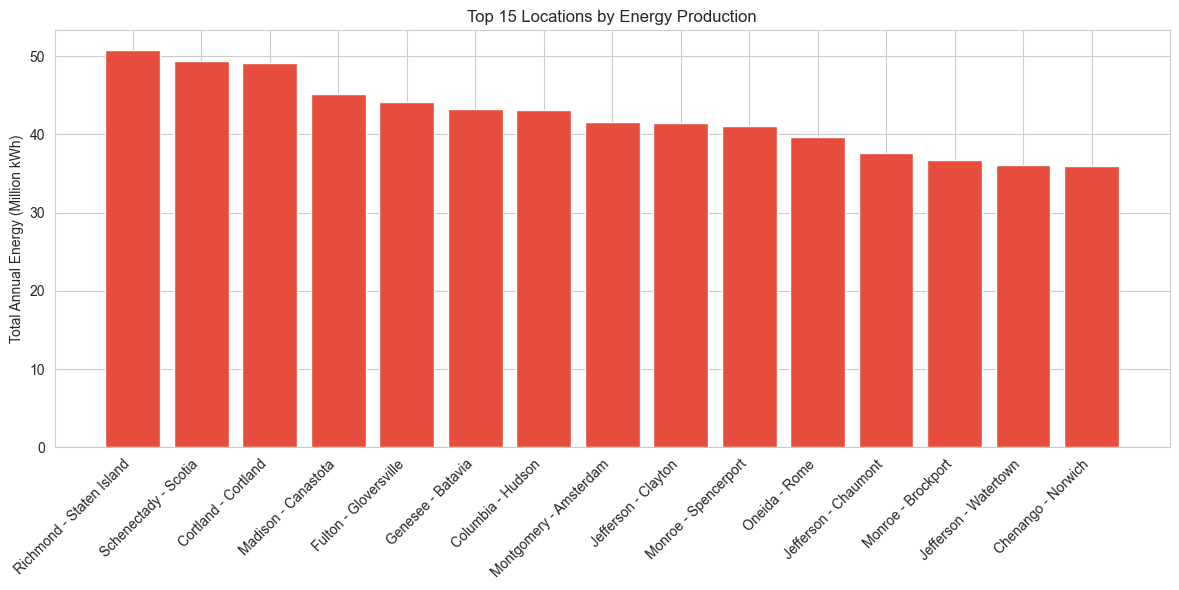

In [17]:
for cid in sorted_clusters:
    zone_df = (agg_df[agg_df['Cluster'] == cid]
               [['County', 'City/Town', 'Zip', 'Total_kWh', 'Total_Projects']]
               .sort_values('Total_kWh', ascending=False)
               .head(10)
               .reset_index(drop=True))
    zone_df.index = zone_df.index + 1

    print(f'\n{zone_names[cid]} — top 10 locations:')
    print(zone_df.to_string())

# zone summary (dropped "Top_County", since a county can span multiple zones)
summary = agg_df.groupby('Zone').agg(
    Locations=('County', 'count'),
    Total_kWh=('Total_kWh', 'sum'),
    Avg_kWh=('Total_kWh', 'mean')
).reindex(zone_names.values())
print('\nZone summary:')
print(summary)

# top 15 locations overall (not counties), colored by zone
top15 = agg_df.nlargest(15, 'Total_kWh')[['County', 'City/Town', 'Zone', 'Total_kWh']]
colors = [zone_colors[sorted_clusters[list(zone_names.values()).index(z)]] for z in top15['Zone']]

plt.figure(figsize=(12, 6))
labels = top15['County'] + ' - ' + top15['City/Town']
plt.bar(labels, top15['Total_kWh'] / 1e6, color=colors)
plt.title('Top 15 Locations by Energy Production')
plt.ylabel('Total Annual Energy (Million kWh)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The top 10 locations in each zone show a real difference in scale, not just rank. The top High Energy Zone location (Richmond/Staten Island) produces 50.7M kWh, more than the Medium zone's entire top 10 combined (each around 3.2-3.8M kWh), and about 480 times the Low zone's top location (New York/New York, 104,765 kWh).

The top 15 locations overall are all from the High Energy Zone, confirming it isn't just more locations, those locations genuinely dominate production. Richmond (Staten Island), Schenectady (Scotia), and Cortland lead, each above 49M kWh.

This gives the sales team a concrete starting list: the High Energy Zone's top locations, led by Staten Island, Scotia, and Cortland, are where to focus first.

## 14. Interactive Map

Plot every location on a map, colored by energy zone, with a popup showing the key numbers for that location. This gives the sales team something they can open and click through directly.

In [18]:
import folium
from folium.plugins import HeatMap

map_df = agg_df.dropna(subset=['Latitude', 'Longitude'])

solar_map = folium.Map(
    location=[map_df['Latitude'].mean(), map_df['Longitude'].mean()],
    zoom_start=7,
    tiles=None
)

folium.TileLayer(
    'https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Street', control=False
).add_to(solar_map)

# one layer per zone, so they can be toggled on/off
zone_groups = {name: folium.FeatureGroup(name=name) for name in zone_names.values()}

for _, row in map_df.iterrows():
    zone = row['Zone']
    color = zone_colors[row['Cluster']]
    popup_text = f"""
    <b>{row['City/Town']}, {row['County']} County</b><br>
    Zone: {zone}<br>
    Annual kWh: {row['Total_kWh']:,.0f}<br>
    Projects: {row['Total_Projects']}
    """
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        color=color,
        weight=1,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(zone_groups[zone])

for group in zone_groups.values():
    group.add_to(solar_map)

# heatmap layer, off by default, viewer can turn it on
heat_data = [[row['Latitude'], row['Longitude'], row['Total_kWh']] for _, row in map_df.iterrows()]
heat_layer = folium.FeatureGroup(name='Heatmap', show=False)
HeatMap(heat_data, radius=15, blur=12).add_to(heat_layer)
heat_layer.add_to(solar_map)

folium.LayerControl(collapsed=False).add_to(solar_map)

solar_map.save('index.html')
solar_map

## 15. Storage Adoption by Zone

Check if battery storage adoption differs across the 3 energy zones, this connects the storage data from earlier to the zone-level business strategy.

                    Total_Locations  With_Storage  Avg_Storage_kWac  \
Zone                                                                  
High Energy Zone                765           492        163.080327   
Medium Energy Zone              884           333          6.862081   
Low Energy Zone                 851            65          0.874172   

                    Storage_Pct  
Zone                             
High Energy Zone          64.31  
Medium Energy Zone        37.67  
Low Energy Zone            7.64  


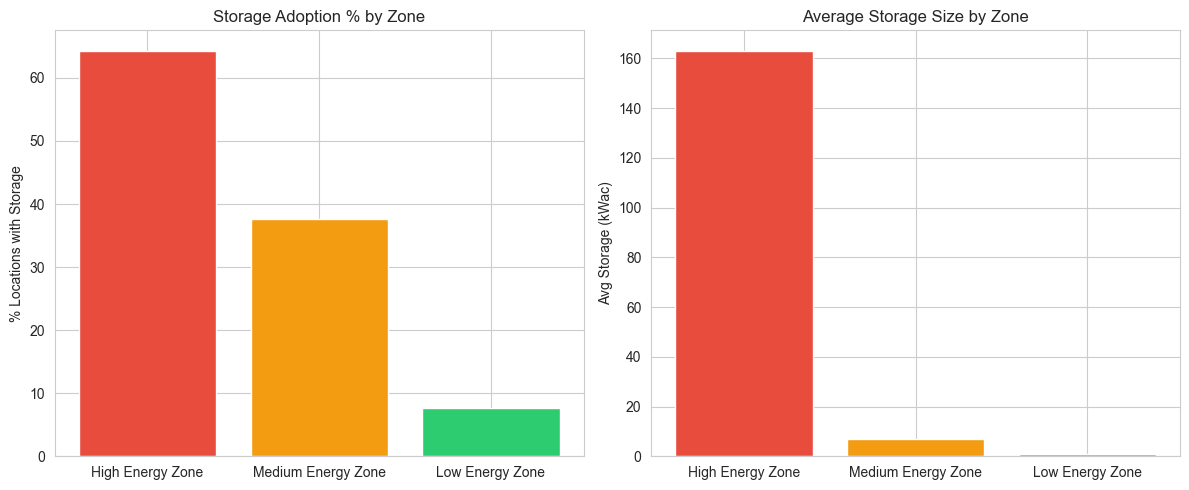

In [19]:
agg_df['Has_Storage_Flag'] = (agg_df['Total_Storage'] > 0).astype(int)

zone_storage = agg_df.groupby('Zone').agg(
    Total_Locations=('County', 'count'),
    With_Storage=('Has_Storage_Flag', 'sum'),
    Avg_Storage_kWac=('Total_Storage', 'mean')
).reindex(zone_names.values())
zone_storage['Storage_Pct'] = (zone_storage['With_Storage'] / zone_storage['Total_Locations'] * 100).round(2)

print(zone_storage)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = [zone_colors[c] for c in sorted_clusters]

axes[0].bar(zone_storage.index, zone_storage['Storage_Pct'], color=colors)
axes[0].set_title('Storage Adoption % by Zone')
axes[0].set_ylabel('% Locations with Storage')

axes[1].bar(zone_storage.index, zone_storage['Avg_Storage_kWac'], color=colors)
axes[1].set_title('Average Storage Size by Zone')
axes[1].set_ylabel('Avg Storage (kWac)')

plt.tight_layout()
plt.show()

Storage adoption is highest in the High Energy Zone (64.3% of locations, averaging 163.1 kWac), drops sharply in the Medium zone (37.7%, averaging 6.9 kWac), and is lowest in the Low zone (7.6%, averaging under 1 kWac). This is the opposite of what might be assumed, storage isn't filling a gap in low-producing areas, it's concentrated where energy production is already highest.

This makes sense: larger, more established solar installations (which dominate the High zone) are more likely to have the budget and infrastructure to add battery storage too. It also means an earlier idea, offering storage incentives specifically to Low zone locations to boost their output, isn't supported by this data; adoption there is low, but it may be low because these are small, minimal installations overall, not because storage was deliberately skipped.

## 16. Final Summary & Recommendations

Pull together the full result: the dataset, the model comparison, the 3 energy zones with their real numbers, and what the business should do with them.

In [20]:
print('Dataset Summary')
print('Total projects analyzed:', len(df))
print('Unique locations clustered:', len(agg_df))
print('Features used:', feature_cols, '(reduced to', X_pca.shape[1], 'PCA components)')
print('Features excluded: Total_Storage (mostly zeros)')

print('\nModel Summary')
print('Algorithms compared: K-Means, DBSCAN, Hierarchical, GMM')
print('Best model:', best_name)
print('K:', optimal_k, '(chosen manually; see Phase 7 for reasoning)')
print('Silhouette:', comparison_df.loc[comparison_df['Model'] == best_name, 'Silhouette'].values[0])
print('Davies-Bouldin:', comparison_df.loc[comparison_df['Model'] == best_name, 'Davies-Bouldin'].values[0])
print('Calinski-Harabasz:', comparison_df.loc[comparison_df['Model'] == best_name, 'Calinski-Harabasz'].values[0])

print('\nEnergy Zones')
for cid in sorted_clusters:
    sub = agg_df[agg_df['Cluster'] == cid]
    print(f'\n{zone_names[cid]}')
    print(f'  Locations: {len(sub)}')
    print(f'  Total kWh/yr: {sub["Total_kWh"].sum():,.0f}')
    print(f'  Avg kWh/yr: {sub["Total_kWh"].mean():,.0f}')
    print(f'  Total Projects: {sub["Total_Projects"].sum():,.0f}')

Dataset Summary
Total projects analyzed: 218085
Unique locations clustered: 2500
Features used: ['Total_kWh', 'Total_kWac', 'Total_kWdc', 'Total_Projects'] (reduced to 2 PCA components)
Features excluded: Total_Storage (mostly zeros)

Model Summary
Algorithms compared: K-Means, DBSCAN, Hierarchical, GMM
Best model: KMeans
K: 3 (chosen manually; see Phase 7 for reasoning)
Silhouette: 0.5175
Davies-Bouldin: 0.6602
Calinski-Harabasz: 5905.66

Energy Zones

High Energy Zone
  Locations: 765
  Total kWh/yr: 5,729,421,492
  Avg kWh/yr: 7,489,440
  Total Projects: 195,958

Medium Energy Zone
  Locations: 884
  Total kWh/yr: 392,565,519
  Avg kWh/yr: 444,079
  Total Projects: 20,241

Low Energy Zone
  Locations: 851
  Total kWh/yr: 21,301,249
  Avg kWh/yr: 25,031
  Total Projects: 1,886


## Conclusion

K-Means with K=3 was the best of the 4 algorithms tested (Silhouette 0.518, Davies-Bouldin 0.660, Calinski-Harabasz 5906), and the clustering was confirmed stable across multiple random seeds. The 2,500 locations split into 3 zones with very different output:

- **High Energy Zone:** 765 locations, averaging 7,489,440 kWh/yr, 5.73 billion kWh/yr combined.
- **Medium Energy Zone:** 884 locations, averaging 444,079 kWh/yr.
- **Low Energy Zone:** 851 locations, averaging 25,031 kWh/yr.

The High zone also has the highest battery storage adoption (64.3%, vs 37.7% Medium and 7.6% Low), these are generally larger, more established installations, not just higher-output ones.

### Recommendations

- **High Energy Zone:** the clearest priority for sales and marketing, based on historical production. This should still be confirmed with site-level feasibility checks before committing investment, clustering shows potential, not a guarantee.
- **Medium Energy Zone:** a reasonable secondary target, with less competition than the High zone.
- **Low Energy Zone:** needs a feasibility study before any investment. Low storage adoption here likely reflects smaller installations overall, not an untapped opportunity for incentives.

### Limitation

This clustering is based on system size, energy output, and project count. It doesn't include solar irradiance or installation cost data, which would better reflect a location's true solar potential. I didn't have access to that external data in this environment, so it's a natural next step for this project.